# Notebook - Find best Drug compound for `Bacillus Anthracis` bacteria. This bacteria is responsible for anthrax disease.

Data source: `PubChem + ChEMBL`

In this notebook, we demonstrate the use of MACAW embeddings to model binding affinity to a protein receptor of pharmacological interest. MACAW embeddings are then applied to identify promising candidate molecules in a custom virtual library.

In [37]:
# warnings/logs
import os
import sys
import warnings
import glob

sys.stderr = open(os.devnull, "w")      # suppress stderr
warnings.filterwarnings("ignore")       # suppress warnings

# Standard library
import csv
import gc
import io
import json
import math
import pickle
import cloudpickle
from copy import deepcopy
from itertools import combinations

# data science library
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde, percentileofscore

# ML library
from joblib import Parallel, delayed, load
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cross_decomposition import PLSRegression
import torch
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModel
from transformers.onnx import OnnxConfig


# chemistry library
from rdkit import Chem, DataStructs
from rdkit.Chem import Draw, Descriptors, rdMolDescriptors, AllChem
from rdkit.Chem.Draw import IPythonConsole  

import pubchempy as pcp
from admet_ai import ADMETModel
from admet_ai.drugbank import get_drugbank


# plotting library
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import matplotlib.patches as patches
from matplotlib.patches import ConnectionPatch
import matplotlib.lines as mlines
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["font.sans-serif"] = ["DejaVu Sans"]
matplotlib.rcParams["figure.dpi"] = 96
matplotlib.rcParams["savefig.dpi"] = 600


# display library
from PIL import Image
from PIL import Image as PILImage
from IPython.display import display, Image as IPImage


# local modules
sys.path.append("../")

import macaw
print(macaw.__version__)
from macaw import *  # if possible, replace with explicit imports

from art.core import RecommendationEngine
import art.utility as utils
from art.plot import predictions_vs_observations, predictions_distr_vs_observations

# notebook management
%run "./plotting.py"
%config InlineBackend.figure_format = "retina"


# functions
def canonicalizeSmiles(smi):
    mol = Chem.MolFromSmiles(smi)
    return Chem.MolToSmiles(mol, canonical=True) if mol else None

1.0.1


## 1. Training Data preparation

In [38]:
dataDir = '/mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/'
modelBuildingDataDir = os.path.join(dataDir, 'modelBuildingData/')
HuggingFaceModelsDir = os.path.join(dataDir, 'HuggingFace_models/')
DORANETmoleculesDataDir = '/users/sghosh6/DTRA_project/MACAW/doranet/scripts'
resultsDir = os.path.join(dataDir, 'Results/BacillusAnthracis_bestMACAW_allDB_generative/')
os.makedirs(resultsDir, exist_ok=True)

### 1.1 Read potency data for BacillusAnthracis Bacteria from `ChEMBL`

In [39]:
allBacteriaData_chEMBL = pd.read_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL_uM.csv')

allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(
    columns={'Virus': 'Bacteria'})
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["molecule_chembl_id", "smiles", "value_uM", "pPotency", "Bacteria"]
)
allBacteriaData_chEMBL['Bacteria'] = allBacteriaData_chEMBL['Bacteria'].str.replace('Data_chEMBL_combined.csv', '', regex=False)
allBacteriaData_chEMBL.rename(columns={'Bacteria': 'BacteriaClassifier'}, inplace=True)

allBacteriaData_chEMBL = allBacteriaData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "BacteriaClassifier" : "Bacteria",
})
allBacteriaData_chEMBL = allBacteriaData_chEMBL.filter(
    items=["Bacteria", "compound_id", "Smiles", "pPotency"])

allBacteriaData_chEMBL['Bacteria'] = (
    allBacteriaData_chEMBL['Bacteria']
    .str.split('_')
    .apply(lambda parts: ''.join(word.capitalize() for word in parts))
)

allBacteriaData_chEMBL.to_csv(modelBuildingDataDir + 'allBacteriaData_chEMBL.csv')
allBacteriaData_chEMBL

,Bacteria,compound_id,Smiles,pPotency
0,BacillusSubtilis,CHEMBL8,O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O,0.250000
1,BacillusSubtilis,CHEMBL606360,COc1ccc(C(=O)/C=C/c2cn(-c3ccccc3)nc2-c2ccc(Cl)...,100.000000
2,BacillusSubtilis,CHEMBL4089761,NC[C@H]1O[C@H](O[C@H]2[C@H](O)[C@@H](O[C@H]3O[...,1.500000
3,BacillusSubtilis,CHEMBL1241817,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)N/N=C/c1cccc(...,16.000000
4,BacillusSubtilis,CHEMBL1242158,O=C(Cn1ncc2cc([N+](=O)[O-])ccc21)NN1C(=O)CSC1c...,16.000000
...,...,...,...,...
163417,YersiniaPestis,CHEMBL4227290,CCCCCCCSSC(=S)N(CC)CC,4.494850
163418,YersiniaPestis,CHEMBL1255631,CC(=O)NCCCC(=O)N[C@@H](Cc1ccccc1)C(=O)N1Cc2ccc...,4.331614
163419,YersiniaPestis,CHEMBL5276443,CC(C)(CNc1ccc(C(N)=O)cn1)c1ccccc1,256.000000
163420,YersiniaPestis,CHEMBL1916867,CSC(=S)N/N=C/c1ccccc1O,5.397940


### Keep only data for `Bacillus_anthracis` bacteria

In [4]:
BacillusAnthracisData_chEMBL = allBacteriaData_chEMBL[allBacteriaData_chEMBL['BacteriaClassifier'] == 'Bacillus_anthracis']
BacillusAnthracisData_chEMBL

,molecule_chembl_id,smiles,value_uM,pPotency,BacteriaClassifier
162379,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,7.585776e+05,0.12,Bacillus_anthracis
162380,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162381,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162382,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,1.000000e+04,2.00,Bacillus_anthracis
162383,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,1.000000e+04,2.00,Bacillus_anthracis
...,...,...,...,...,...
163230,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,1.000000e+01,5.00,Bacillus_anthracis
163231,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],1.000000e-44,50.00,Bacillus_anthracis
163232,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,1.000000e-194,200.00,Bacillus_anthracis
163233,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,1.584893e-02,7.80,Bacillus_anthracis


### Rename columns

In [5]:
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.rename(columns={
    "molecule_chembl_id": "compound_id",
    "smiles": "Smiles",
    "BacteriaClassifier" : "Bacteria",
})
BacillusAnthracisData_chEMBL = BacillusAnthracisData_chEMBL.filter(
    items=["Bacteria", "compound_id", "Smiles", "pPotency"])
BacillusAnthracisData_chEMBL

,Bacteria,compound_id,Smiles,pPotency
162379,Bacillus_anthracis,CHEMBL1257070,Cc1oc(=O)oc1COC(=O)C1=C([C@H]2CCCO2)S[C@@H]2[C...,0.12
162380,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162381,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162382,Bacillus_anthracis,CHEMBL29,CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@...,2.00
162383,Bacillus_anthracis,CHEMBL529,CC[C@H]1OC(=O)[C@H](C)[C@@H](O[C@H]2C[C@@](C)(...,2.00
...,...,...,...,...
163230,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.00
163231,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.00
163232,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.00
163233,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.80


### 1.2 Read `Pubchem` bioassay data for BacillusAnthracis Bacteria

In [44]:
# Keep only data for Bacillus_anthracis Bacteria
BacillusAnthracisData_Pubchem = pd.read_csv(os.path.join(modelBuildingDataDir, "allBacteria_Pubchem.csv"))
BacillusAnthracisData_Pubchem = BacillusAnthracisData_Pubchem[BacillusAnthracisData_Pubchem['Bacteria'] == 'BacillusAnthracis']
BacillusAnthracisData_Pubchem

,Unnamed: 0,Bacteria,compound_id,Smiles,pPotency
0,0,BacillusAnthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,1,BacillusAnthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,2,BacillusAnthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,3,BacillusAnthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,4,BacillusAnthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...,...
3477,3477,BacillusAnthracis,7117403,O=C(C(=O)N1CC=C(c2ccccc2)CC1)c1c[nH]c2ccccc12,4.920819
3478,3478,BacillusAnthracis,54595320,N#Cc1ccc(Oc2ccccc2O)c(F)c1,4.958607
3479,3479,BacillusAnthracis,43458374,CN(Cc1ccccc1N)C(=O)c1cc2ccccc2o1,4.346787
3480,3480,BacillusAnthracis,4117778,O=C(COc1ccccc1)NCCSc1c[nH]c2ccccc12,5.468521


### Combine `Pubchem + chEMBL` data

In [7]:
BacillusAnthracisData_allDB = pd.concat(
    [BacillusAnthracisData_Pubchem, BacillusAnthracisData_chEMBL],
    ignore_index=True
)

BacillusAnthracisData_allDB

,Bacteria,compound_id,Smiles,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Canonicalize the `Smiles`

In [8]:
BacillusAnthracisData_allDB['Smiles'] = (
    BacillusAnthracisData_allDB['Smiles']
    .astype(str)
    .apply(canonicalizeSmiles)
)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.rename(
    columns={'Smiles': 'Canonical_SMILES'})

BacillusAnthracisData_allDB

,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Remove `Basidalin + other compounds` from training set

In [9]:
querySmilesDict = {
    "Basidalin": "C1=C(/C(=C\C=O)/OC1=O)N",
    "Basidalin_Precursor" : "CCC=C1OC(=O)[C@@H](C)[C@H]1O",
    "Gatifloxacin": "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline": "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin": "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G": "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}

In [10]:
# Canonical SMILES set for all query drugs
queryCanonicalSet = {
    Chem.MolToSmiles(Chem.MolFromSmiles(smi), canonical=True)
    for smi in querySmilesDict.values()
    if Chem.MolFromSmiles(smi) is not None
}

# Canonicalize all SMILES in your dataframe
df = BacillusAnthracisData_allDB.copy()
df["canonical_smiles"] = df["Canonical_SMILES"].apply(
    lambda s: Chem.MolToSmiles(Chem.MolFromSmiles(s), canonical=True)
    if Chem.MolFromSmiles(s) is not None else None
)

# Remove rows whose canonical SMILES appear in querySmilesDict
df_clean = df[~df["canonical_smiles"].isin(queryCanonicalSet)].copy()

print(f"Original shape: {len(df)}")
print(f"Removed (matches any query drug): {len(df) - len(df_clean)}")
print(f"Remaining shape: {len(df_clean)}")

BacillusAnthracisData_allDB = df_clean.copy()
BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.drop(columns='canonical_smiles')
BacillusAnthracisData_allDB

Original shape: 4338
Removed (matches any query drug): 111
Remaining shape: 4227


,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4334,Bacillus_anthracis,CHEMBL1922604,CC(=O)N(O)CCCP(=O)([O-])O.[Na+],50.000000
4335,Bacillus_anthracis,CHEMBL1922611,CC(=O)N(O)CCCP(=O)(OC(C)OC(=O)OC(C)(C)C)OC(C)O...,200.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


### Potency distribution

In [11]:
# bins for non-negative values: 0-3, 3-4, ..., 11-12, >12
bins = [0] + list(range(3, 13)) + [np.inf]
labels = ["0-3"] + [f"{i}-{i+1}" for i in range(3, 12)] + ["> 12"]

df = BacillusAnthracisData_allDB.copy()

# coerce to numeric (invalid entries become NaN)
p = pd.to_numeric(df["pPotency"], errors="coerce")

# build categories including NaN and negatives
cat = pd.Series(index=df.index, dtype="object")
cat[p.isna()] = "NaN"
cat[(~p.isna()) & (p < 0)] = "<0"

# categorize non-negative values
cat[(~p.isna()) & (p >= 0)] = pd.cut(
    p[(~p.isna()) & (p >= 0)],
    bins=bins,
    labels=labels,
    right=False,
    ordered=True,
)

df["pPotency_category"] = cat

order = ["NaN", "<0"] + labels
category_counts = df["pPotency_category"].value_counts().reindex(order, fill_value=0)
total = category_counts.sum()
category_percent = (category_counts / total * 100).round(0).astype(int)

potencyDist = pd.DataFrame({
    "pPotency Range": category_counts.index.astype(str),
    "Count": category_counts.values,
    "Percent (%)": category_percent.values
})

potencyDist

,pPotency Range,Count,Percent (%)
0,NaN,73,2
1,<0,0,0
2,0-3,733,17
3,3-4,551,13
4,4-5,1357,32
5,5-6,761,18
6,6-7,297,7
7,7-8,121,3
8,8-9,95,2
9,9-10,48,1


### Remove NaN, -ve and unphysical (>12) values in `pPotency` before running cross-validation

| Range (pPotency) | IC₅₀/EC₅₀ (in M)          | Interpretation                                | Action              |
| ---------------- | -------------------- | --------------------------------------------- | ------------------- |
| **0–3**   | > 1×10⁻³ M (millimolar)     | Very weak or inactive compounds               | **Keep**         |
| **3–10**  | 1×10⁻³ – 1×10⁻¹⁰ M          | Normal drug-like activity range               | **Keep**                |
| **10–12** | 1×10⁻¹⁰ – 1×10⁻¹² M         | Extremely potent but still physically possible | **Keep** |
| **>12**   | < 1×10⁻¹² M (picomolar–femto) | Physically unrealistic / likely data error     | Drop                |



In [12]:
print("Original shape:", BacillusAnthracisData_allDB.shape)

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB[
    BacillusAnthracisData_allDB['pPotency'].notna()
    & BacillusAnthracisData_allDB['pPotency'].between(0, 12, inclusive="both")]

BacillusAnthracisData_allDB = BacillusAnthracisData_allDB.drop(
    columns=["canonical_smiles", "pPotency_category"],
    errors="ignore"  # prevents error if a column doesn't exist
)
print("Shape after cleaning 'pPotency' value:", BacillusAnthracisData_allDB.shape)
max_val = BacillusAnthracisData_allDB['pPotency'].max()
min_val = BacillusAnthracisData_allDB['pPotency'].min()
print(f"pPotency range in training data: {min_val:.3f} → {max_val:.3f}")

BacillusAnthracisData_allDB

Original shape: (4227, 4)
Shape after cleaning 'pPotency' value: (3973, 4)
pPotency range in training data: 0.015 → 12.000


,Bacteria,compound_id,Canonical_SMILES,pPotency
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996
...,...,...,...,...
4330,Bacillus_anthracis,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606
4332,Bacillus_anthracis,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000


In [13]:
BacillusAnthracisData_allDB.to_csv(resultsDir +  "BacillusAnthracisData_allDB_MLready.csv", index=False)

### Checking how many duplicate SMILES are present in the training data set

In [14]:
duplicates = BacillusAnthracisData_allDB.duplicated(subset=['Canonical_SMILES', 'Bacteria'])
print("Remaining duplicates:", duplicates.sum())

Remaining duplicates: 2329


## 2.1 Find best `MACAW` parameters to train ML Model

MACAW(n_components=30, n_landmarks=500) -> Test R²=0.471, Train R²=0.487
MACAW(n_components=30, n_landmarks=750) -> Test R²=0.450, Train R²=0.466
MACAW(n_components=30, n_landmarks=1000) -> Test R²=0.468, Train R²=0.476
MACAW(n_components=30, n_landmarks=1250) -> Test R²=0.468, Train R²=0.477
MACAW(n_components=30, n_landmarks=1500) -> Test R²=0.461, Train R²=0.466
MACAW(n_components=45, n_landmarks=500) -> Test R²=0.481, Train R²=0.502
MACAW(n_components=45, n_landmarks=750) -> Test R²=0.481, Train R²=0.499
MACAW(n_components=45, n_landmarks=1000) -> Test R²=0.504, Train R²=0.517
MACAW(n_components=45, n_landmarks=1250) -> Test R²=0.469, Train R²=0.489
MACAW(n_components=45, n_landmarks=1500) -> Test R²=0.483, Train R²=0.501
MACAW(n_components=60, n_landmarks=500) -> Test R²=0.523, Train R²=0.543
MACAW(n_components=60, n_landmarks=750) -> Test R²=0.518, Train R²=0.537
MACAW(n_components=60, n_landmarks=1000) -> Test R²=0.504, Train R²=0.528
MACAW(n_components=60, n_landmarks=1250) -> 

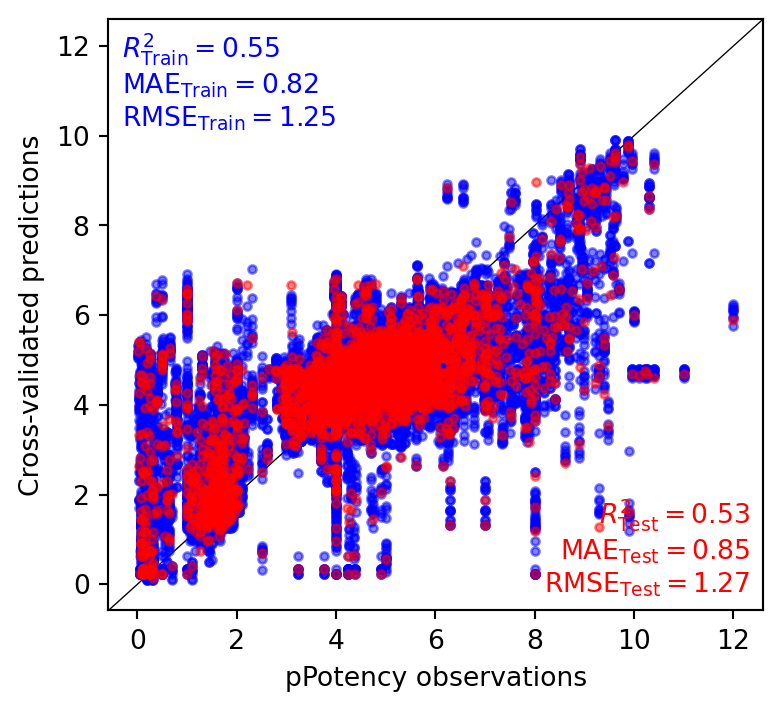

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW_worst_nc30_nl750.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW_worst_nc30_nl750.png


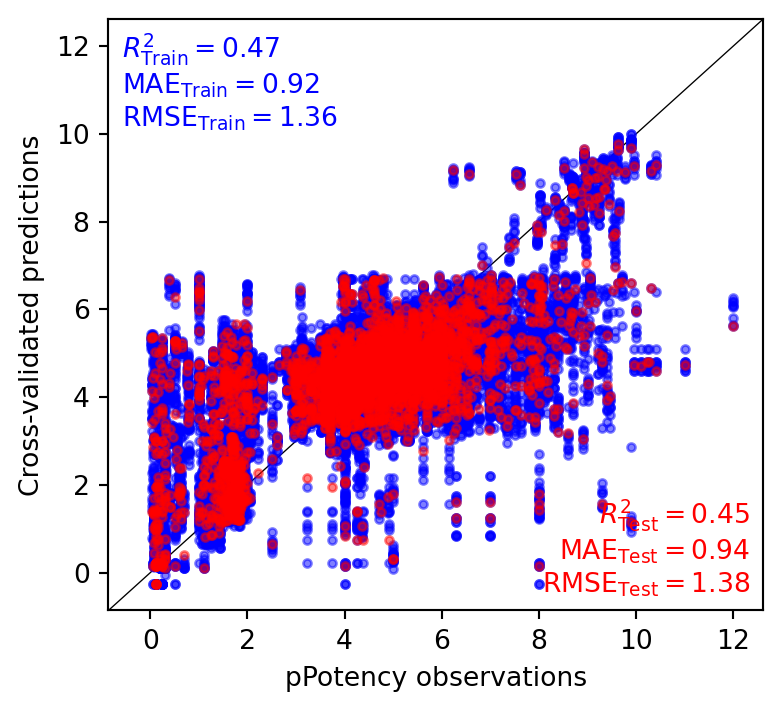

In [15]:
Y      = BacillusAnthracisData_allDB["pPotency"]
smiles = BacillusAnthracisData_allDB["Canonical_SMILES"]

valid  = Y.notna() & smiles.notna()
Y      = Y[valid].reset_index(drop=True)
smiles = smiles[valid].reset_index(drop=True)

kf    = KFold(n_splits=10, shuffle=True, random_state=42)
folds = list(kf.split(smiles))

param_grid = {
    "C":       [1, 10, 50, 100, 300],
    "gamma":   ["scale", 0.01, 0.05, 0.1],
    "epsilon": [0.1, 0.5, 1, 3],
    "kernel":  ["rbf"],
}

nComponentsList = [30, 45, 60, 90]
nLandmarksList  = [500, 750, 1000, 1250, 1500]

def run_fold(train_idx, test_idx, baseMacaw):
    smiTrain = smiles.iloc[train_idx]
    smiTest  = smiles.iloc[test_idx]
    yTrain   = Y.iloc[train_idx].values
    yTest    = Y.iloc[test_idx].values
    macaw    = deepcopy(baseMacaw)
    macaw.fit(smiTrain, yTrain)
    XTrain   = macaw.transform(smiTrain)
    XTest    = macaw.transform(smiTest)
    grid     = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(XTrain, yTrain)
    return (yTrain, grid.predict(XTrain), yTest, grid.predict(XTest))

results = []
for n_components in nComponentsList:
    for n_landmarks in nLandmarksList:
        baseMacaw = MACAW(
            type_fp="atompairs", metric="sokal",
            n_components=n_components, n_landmarks=n_landmarks,
            random_state=42
        )
        foldPreds = Parallel(n_jobs=16)(
            delayed(run_fold)(tr, te, baseMacaw) for tr, te in folds
        )
        yObsTrainAll  = np.concatenate([r[0] for r in foldPreds])
        yPredTrainAll = np.concatenate([r[1] for r in foldPreds])
        yObsTestAll   = np.concatenate([r[2] for r in foldPreds])
        yPredTestAll  = np.concatenate([r[3] for r in foldPreds])

        trainR2 = r2_score(yObsTrainAll, yPredTrainAll)
        testR2  = r2_score(yObsTestAll, yPredTestAll)
        gapR2   = trainR2 - testR2

        results.append({
            "n_components":  n_components,
            "n_landmarks":   n_landmarks,
            "trainR2":       trainR2,
            "testR2":        testR2,
            "gapR2":         gapR2,
            "testMAE":       mean_absolute_error(yObsTestAll, yPredTestAll),
            "testRMSE":      np.sqrt(mean_squared_error(yObsTestAll, yPredTestAll)),
            "yObsTrainAll":  yObsTrainAll,
            "yPredTrainAll": yPredTrainAll,
            "yObsTestAll":   yObsTestAll,
            "yPredTestAll":  yPredTestAll,
        })
        print(f"MACAW({n_components=}, {n_landmarks=}) -> Test R²={testR2:.3f}, Train R²={trainR2:.3f}")

macawResultsDF = pd.DataFrame(results)
best  = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]
worst = macawResultsDF.sort_values("testR2", ascending=True).iloc[0]

macawNComponents = int(best["n_components"])
macawNLandmarks  = int(best["n_landmarks"])

print(f"\nBest MACAW parameters : n_components={macawNComponents}, n_landmarks={macawNLandmarks}")
print(f"  Test R²={best['testR2']:.3f}, Train R²={best['trainR2']:.3f}, Gap={best['gapR2']:.3f}")
print(f"\nWorst MACAW parameters: n_components={int(worst['n_components'])}, n_landmarks={int(worst['n_landmarks'])}")
print(f"  Test R²={worst['testR2']:.3f}, Train R²={worst['trainR2']:.3f}, Gap={worst['gapR2']:.3f}")

for tag, row in [("best", best), ("worst", worst)]:
    nc = int(row["n_components"])
    nl = int(row["n_landmarks"])
    parity_plot(
        x=row["yObsTrainAll"], y=row["yPredTrainAll"],
        x_test=row["yObsTestAll"], y_test=row["yPredTestAll"],
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=resultsDir + f"BacillusAnthracis_allDB_CV_wMACAW_{tag}_nc{nc}_nl{nl}.svg",
        save_formats=["svg", "png"],
    )

### Run cross validation with best `MACAW` parameters

In [16]:
macawResultsDF = pd.DataFrame(results)
best = macawResultsDF.sort_values("testR2", ascending=False).iloc[0]

macawNComponents = int(best["n_components"])
macawNLandmarks  = int(best["n_landmarks"])

print(f"Best MACAW parameters: macawNComponents={macawNComponents}, macawNLandmarks={macawNLandmarks}")
print(f"  Test R²={best['testR2']:.3f}, Train R²={best['trainR2']:.3f}, Gap={best['gapR2']:.3f}")

Best MACAW parameters: macawNComponents=90, macawNLandmarks=750
  Test R²=0.530, Train R²=0.546, Gap=0.016


Model training with: 3973 instances

----------------------------------------
Cross Validation Metrics
----------------------------------------
Train: MAE 0.46 | RMSE 0.93 | R² 0.75
Test:  MAE 0.64 | RMSE 1.10 | R² 0.65
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW.svg
Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracis_allDB_CV_wMACAW.png


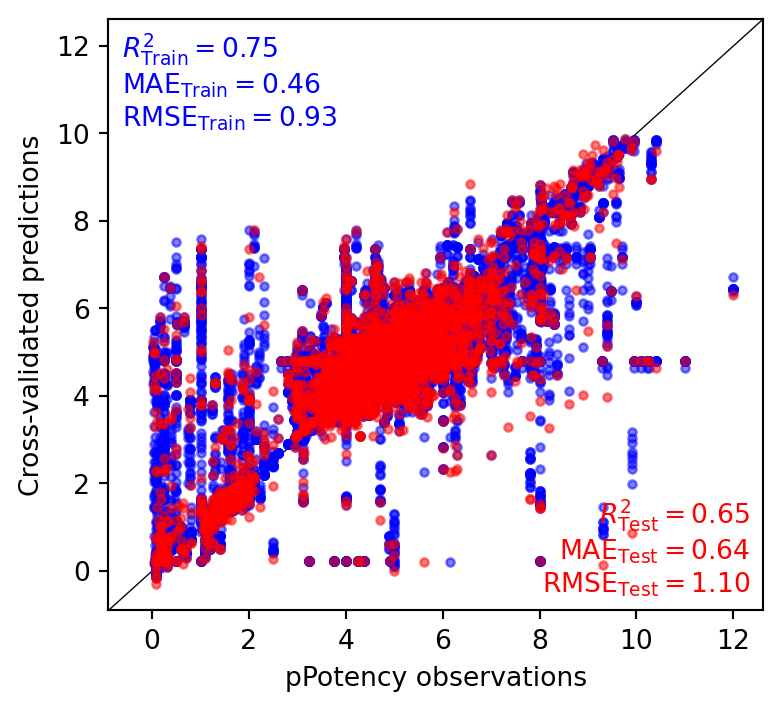

In [17]:
# --- Data ---
Y = BacillusAnthracisData_allDB["pPotency"]
smiles = BacillusAnthracisData_allDB["Canonical_SMILES"]

# CV partitions
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mcw = MACAW(
    type_fp="atompairs", metric="sokal",
    n_components=macawNComponents, n_landmarks=macawNLandmarks, random_state=42
)

param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

# Clean NaNs in target
valid = Y.notna()
smiles = smiles[valid].reset_index(drop=True)
Y = Y[valid].reset_index(drop=True)

print(f"Model training with: {len(smiles)} instances")

def process_fold(fold_id, train_idx, test_idx):
    smi_train, smi_test = smiles.iloc[train_idx], smiles.iloc[test_idx]
    y_train, y_test = Y.iloc[train_idx].values, Y.iloc[test_idx].values

    mcw_fold = deepcopy(mcw)
    mcw_fold.fit(smi_train, y_train)

    X_train = mcw_fold.transform(smi_train)
    X_test = mcw_fold.transform(smi_test)

    grid = GridSearchCV(SVR(), param_grid, cv=5, refit=True)
    grid.fit(X_train, y_train)

    pred_train = grid.predict(X_train)
    pred_test  = grid.predict(X_test)

    return pred_train, y_train, pred_test, y_test, grid.best_params_

folds = list(kf.split(smiles))

results = Parallel(n_jobs=4)(
    delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
)

# Concatenate CV predictions
Y_pred_train = np.concatenate([r[0] for r in results])
Y_obs_train  = np.concatenate([r[1] for r in results])
Y_pred_test  = np.concatenate([r[2] for r in results])
Y_obs_test   = np.concatenate([r[3] for r in results])

best_params_per_fold = [r[4] for r in results]

# --- Metrics ---
def metrics(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        r2_score(y_true, y_pred),
    )

train_mae, train_rmse, train_r2 = metrics(Y_obs_train, Y_pred_train)
test_mae,  test_rmse,  test_r2  = metrics(Y_obs_test,  Y_pred_test)

print("\n" + "-"*40)
print("Cross Validation Metrics")
print("-"*40)
print(f"Train: MAE {train_mae:.2f} | RMSE {train_rmse:.2f} | R² {train_r2:.2f}")
print(f"Test:  MAE {test_mae:.2f} | RMSE {test_rmse:.2f} | R² {test_r2:.2f}")

parity_plot(
    x=Y_obs_train, y=Y_pred_train,
    x_test=Y_obs_test, y_test=Y_pred_test,
    xlabel="pPotency observations",
    ylabel="Cross-validated predictions",
    savetitle=resultsDir + "BacillusAnthracis_allDB_CV_wMACAW.svg",
    save_formats=["svg", "png"],
)

### Create `MACAW` embeedings with `best parameters`to run `ART`

In [18]:
# Fit MACAW on SMILES and pPotency
mcw.fit(BacillusAnthracisData_allDB['Canonical_SMILES'], BacillusAnthracisData_allDB['pPotency'])

# Save MACAW transformer
macaw_save_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_save_path, 'wb') as f:
    pickle.dump(mcw, f)
print(f"MACAW transformer saved to: {macaw_save_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BacillusAnthracisData_allDB['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BacillusAnthracisData_allDB.index)


# Add new MACAW columns to existing data frame 
BacillusAnthracisData_allDB_wMACAW = pd.concat([BacillusAnthracisData_allDB, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BacillusAnthracisData_allDB.shape}")
print(f"New dataframe shape: {BacillusAnthracisData_allDB_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BacillusAnthracisData_allDB_wMACAW.to_csv(os.path.join(resultsDir, "BacillusAnthracisData_allDB_wMACAW.csv"), index=False)
BacillusAnthracisData_allDB_wMACAW

MACAW transformer saved to: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_MACAW_transformer.joblib
MACAW embeddings shape: (3973, 90)

Original dataframe shape: (3973, 4)
New dataframe shape: (3973, 94)

New columns added: ['MACAW_1', 'MACAW_2', 'MACAW_3', 'MACAW_4', 'MACAW_5', 'MACAW_6', 'MACAW_7', 'MACAW_8', 'MACAW_9', 'MACAW_10', 'MACAW_11', 'MACAW_12', 'MACAW_13', 'MACAW_14', 'MACAW_15', 'MACAW_16', 'MACAW_17', 'MACAW_18', 'MACAW_19', 'MACAW_20', 'MACAW_21', 'MACAW_22', 'MACAW_23', 'MACAW_24', 'MACAW_25', 'MACAW_26', 'MACAW_27', 'MACAW_28', 'MACAW_29', 'MACAW_30', 'MACAW_31', 'MACAW_32', 'MACAW_33', 'MACAW_34', 'MACAW_35', 'MACAW_36', 'MACAW_37', 'MACAW_38', 'MACAW_39', 'MACAW_40', 'MACAW_41', 'MACAW_42', 'MACAW_43', 'MACAW_44', 'MACAW_45', 'MACAW_46', 'MACAW_47', 'MACAW_48', 'MACAW_49', 'MACAW_50', 'MACAW_51', 'MACAW_52', 'MACAW_53', 'MACAW_54', 'MACAW_55', 'MACAW_56', 'MACAW_57', 

,Bacteria,compound_id,Canonical_SMILES,pPotency,MACAW_1,MACAW_2,MACAW_3,MACAW_4,MACAW_5,MACAW_6,...,MACAW_81,MACAW_82,MACAW_83,MACAW_84,MACAW_85,MACAW_86,MACAW_87,MACAW_88,MACAW_89,MACAW_90
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,0.089187,0.054482,0.010205,-0.054983,-0.003048,0.174043,...,-0.015652,-0.016167,-0.002906,0.010132,-0.007308,-0.042257,-0.010060,-0.031955,-0.015985,0.024043
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,0.093178,0.223556,-0.021122,-0.008310,0.003602,0.028055,...,-0.079437,0.033281,-0.006370,0.024434,-0.002382,0.007016,-0.024456,0.009651,-0.023174,-0.029280
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,0.053747,0.159494,0.055060,-0.040939,0.037757,0.018884,...,-0.014563,-0.035781,-0.005395,0.013656,-0.026490,-0.033263,-0.019546,0.042302,-0.006637,0.005013
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,0.093178,0.223556,-0.021122,-0.008310,0.003602,0.028055,...,-0.079437,0.033281,-0.006370,0.024434,-0.002382,0.007016,-0.024456,0.009651,-0.023174,-0.029280
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,0.053747,0.159494,0.055060,-0.040939,0.037757,0.018884,...,-0.014563,-0.035781,-0.005395,0.013656,-0.026490,-0.033263,-0.019546,0.042302,-0.006637,0.005013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4330,Bacillus_anthracis,CHEMBL560502,CCCC1c2ccccc2C=NN1C(=O)/C=C/c1cc(Cc2cnc(N)nc2N...,7.267606,0.173686,0.094242,-0.140713,-0.153484,0.102573,-0.079497,...,0.014793,0.017659,-0.061757,-0.038782,-0.012128,-0.039847,-0.029942,0.005613,-0.041783,-0.011362
4332,Bacillus_anthracis,CHEMBL561523,COc1cc(/C=C2\SC(=S)N(c3cccc(C(F)(F)F)c3)C2=O)c...,4.022276,-0.016580,0.075214,-0.048050,-0.057607,0.022323,0.074051,...,-0.050426,0.037498,-0.010496,-0.068585,0.006517,-0.045842,0.022439,0.040603,-0.017668,0.078417
4333,Bacillus_anthracis,CHEMBL560919,Cc1c(Cc2ccccc2)c(=O)oc2c(O)c(O)ccc12,5.000000,-0.099575,0.079391,0.047676,0.010712,0.047101,0.174390,...,0.025850,-0.004378,-0.014877,-0.034290,0.004042,-0.022815,0.002028,0.001148,-0.011093,-0.017538
4336,Bacillus_anthracis,CHEMBL5191499,O=C1CC(c2ccccc2)=NN1c1nc2ccccc2[nH]c1=O,7.800000,-0.051055,0.191162,0.016459,0.033043,0.048307,0.068722,...,-0.018130,0.003658,0.010473,0.007880,-0.020198,-0.001075,-0.010408,-0.011088,0.010491,0.008905


## 2.2 Compute `ChemBERTa/MoLFormer/MIST` embeddings

In [19]:
smilesCol = "Canonical_SMILES"
targetCol = "pPotency"
idCol = "compound_id"
strainCol = "StrainClassifier"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

Using device: cpu


### Define helper functions

In [20]:
def meanPoolTokenEmbeddings(tokenEmbeddings, attentionMask):
    mask = attentionMask.unsqueeze(-1).expand_as(tokenEmbeddings).float()
    return (tokenEmbeddings * mask).sum(dim=1) / torch.clamp(mask.sum(dim=1), min=1e-9)


def firstTokenPoolTokenEmbeddings(tokenEmbeddings):
    return tokenEmbeddings[:, 0, :]


def extractTokenEmbeddings(outputs):
    if getattr(outputs, "last_hidden_state", None) is not None:
        return outputs.last_hidden_state
    if isinstance(outputs, tuple) and len(outputs) > 0:
        return outputs[0]
    if getattr(outputs, "hidden_states", None) is not None:
        return outputs.hidden_states[-1]
    raise RuntimeError("Cannot extract token embeddings from model output.")


def loadTokenizer(modelName, trustRemoteCode=False, useMistFallback=False, localFilesOnly=True):
    try:
        tokenizer = AutoTokenizer.from_pretrained(
            modelName,
            trust_remote_code=trustRemoteCode,
            local_files_only=localFilesOnly,
        )
    except Exception as err:
        if not useMistFallback:
            raise err

        print("AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.")
        print(f"Original tokenizer error: {err}")

        from smirk import SmirkTokenizerFast

        try:
            tokenizer = SmirkTokenizerFast.from_pretrained(
                modelName,
                local_files_only=localFilesOnly,
            )
        except TypeError:
            tokenizer = SmirkTokenizerFast.from_pretrained(modelName)

    if tokenizer.pad_token is None:
        for attr in ["eos_token", "cls_token", "sep_token", "unk_token"]:
            token = getattr(tokenizer, attr, None)
            if token is not None:
                tokenizer.pad_token = token
                break

    if tokenizer.pad_token is None:
        raise ValueError(f"No pad token found for tokenizer: {modelName}")

    return tokenizer


def runModelForward(model, encoded):
    try:
        return model(**encoded)
    except TypeError as err:
        if "token_type_ids" in str(err) and "token_type_ids" in encoded:
            encoded = {k: v for k, v in encoded.items() if k != "token_type_ids"}
            return model(**encoded)
        raise err


def embedSmilesToArray(
    validSmilesList,
    tokenizer,
    model,
    poolingFn,
    device,
    batchSize,
    maxLength,
    dtype=np.float32,
):
    allEmbeddings = []

    with torch.inference_mode():
        for startIdx in tqdm(range(0, len(validSmilesList), batchSize)):
            batchSmiles = validSmilesList[startIdx:startIdx + batchSize]

            encoded = tokenizer(
                batchSmiles,
                padding=True,
                truncation=True,
                max_length=maxLength,
                return_tensors="pt",
            )
            encoded = {k: v.to(device) for k, v in encoded.items()}

            outputs = runModelForward(model, encoded)
            tokenEmbeddings = extractTokenEmbeddings(outputs)

            if poolingFn == meanPoolTokenEmbeddings:
                pooled = poolingFn(tokenEmbeddings, encoded["attention_mask"])
            else:
                pooled = poolingFn(tokenEmbeddings)

            allEmbeddings.append(pooled.detach().cpu().numpy().astype(dtype))

    return np.vstack(allEmbeddings)


def smilesToEmbeddings(
    DF,
    modelName,
    featurePrefix,
    smilesCol="Canonical_SMILES",
    pooling="mean",
    batchSize=64,
    maxLength=512,
    trustRemoteCode=False,
    useMistFallback=False,
    featureIndexFmt="{prefix}_{i}",
    keepCleanSmiles=False,
    dtype=np.float32,
    device=None,
    localFilesOnly=True,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    poolingFnDict = {
        "mean": meanPoolTokenEmbeddings,
        "cls": firstTokenPoolTokenEmbeddings,
    }

    if pooling not in poolingFnDict:
        raise ValueError(f"pooling must be 'mean' or 'cls', got: {pooling}")

    if localFilesOnly and not os.path.exists(modelName):
        raise FileNotFoundError(f"Local model folder not found:\n{modelName}")

    outDF = DF.copy()
    cleanSmilesCol = f"{smilesCol}_clean"
    outDF[cleanSmilesCol] = outDF[smilesCol].apply(canonicalizeSmiles)

    validMask = outDF[cleanSmilesCol].notna()
    validSmilesList = outDF.loc[validMask, cleanSmilesCol].astype(str).tolist()

    print(f"Model           : {modelName}")
    print(f"Feature prefix  : {featurePrefix} | Pooling: {pooling}")
    print(f"Total / valid / invalid: {len(outDF)} / {len(validSmilesList)} / {(~validMask).sum()}")
    print(f"Device: {device} | Batch size: {batchSize} | Max length: {maxLength}")
    print(f"Local files only: {localFilesOnly}")

    if not validSmilesList:
        raise ValueError("No valid SMILES found.")

    tokenizer = loadTokenizer(
        modelName,
        trustRemoteCode=trustRemoteCode,
        useMistFallback=useMistFallback,
        localFilesOnly=localFilesOnly,
    )

    model = AutoModel.from_pretrained(
        modelName,
        trust_remote_code=trustRemoteCode,
        local_files_only=localFilesOnly,
    ).to(device).eval()

    embeddingArrayValid = embedSmilesToArray(
        validSmilesList,
        tokenizer,
        model,
        poolingFnDict[pooling],
        device,
        batchSize,
        maxLength,
        dtype,
    )

    nFeatures = embeddingArrayValid.shape[1]
    featureCols = [
        featureIndexFmt.format(prefix=featurePrefix, i=i)
        for i in range(nFeatures)
    ]

    embeddingArrayAll = np.full((len(outDF), nFeatures), np.nan, dtype=dtype)
    embeddingArrayAll[validMask.values] = embeddingArrayValid

    embeddingDF = pd.DataFrame(
        embeddingArrayAll,
        columns=featureCols,
        index=outDF.index,
    )

    outDF = pd.concat([outDF, embeddingDF], axis=1)

    if not keepCleanSmiles:
        outDF = outDF.drop(columns=[cleanSmilesCol])

    del model
    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return outDF, featureCols

In [21]:
localModelDict = {
    "ChemBERTa_zinc_base": os.path.join(HuggingFaceModelsDir, "ChemBERTa_zinc_base"),
    "MoLFormer_XL": os.path.join(HuggingFaceModelsDir, "MoLFormer_XL_both_10pct"),
    "MIST_28M": os.path.join(HuggingFaceModelsDir, "MIST_28M"),
}

for modelKey, modelPath in localModelDict.items():
    if os.path.exists(modelPath):
        print(f"Found:   {modelKey} -> {modelPath}")
    else:
        print(f"Missing: {modelKey} -> {modelPath}")

Found:   ChemBERTa_zinc_base -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/ChemBERTa_zinc_base
Found:   MoLFormer_XL -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MoLFormer_XL_both_10pct
Found:   MIST_28M -> /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MIST_28M


### Generate `ChemBERTa` embeddings

In [22]:
chemBertaModelPath = localModelDict["ChemBERTa_zinc_base"]

BacillusAnthracisData_allDB_wChemBERTa, chemBertaFeatureCols = smilesToEmbeddings(
    DF              = BacillusAnthracisData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = chemBertaModelPath,
    featurePrefix   = "ChemBERTa",
    pooling         = "mean",
    batchSize       = 64,
    maxLength       = 256,
    trustRemoteCode = False,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

chemBertaOutputFile = resultsDir + "BacillusAnthracisData_allDB_wChemBERTa.csv"
BacillusAnthracisData_allDB_wChemBERTa.to_csv(chemBertaOutputFile, index=False)

print(f"Saved: {chemBertaOutputFile}  |  ChemBERTa feature count: {len(chemBertaFeatureCols)}")
BacillusAnthracisData_allDB_wChemBERTa.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/ChemBERTa_zinc_base
Feature prefix  : ChemBERTa | Pooling: mean
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 64 | Max length: 256
Local files only: True


  0%|          | 0/63 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_wChemBERTa.csv  |  ChemBERTa feature count: 768


,Bacteria,compound_id,Canonical_SMILES,pPotency,ChemBERTa_0,ChemBERTa_1,ChemBERTa_2,ChemBERTa_3,ChemBERTa_4,ChemBERTa_5,...,ChemBERTa_758,ChemBERTa_759,ChemBERTa_760,ChemBERTa_761,ChemBERTa_762,ChemBERTa_763,ChemBERTa_764,ChemBERTa_765,ChemBERTa_766,ChemBERTa_767
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,0.437796,0.122159,-0.068750,-0.146084,0.325629,-0.047482,...,0.026931,0.799653,-0.218548,-0.541777,-0.208826,0.650611,0.176533,0.163386,-0.577268,0.291470
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,0.682398,0.395218,0.231133,-0.433446,0.228651,0.551066,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,0.578278,0.086702,0.532358,-0.791884,0.393951,0.021618,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,0.682398,0.395218,0.231133,-0.433446,0.228651,0.551066,...,0.162065,0.785158,-0.195066,-0.785304,-0.668540,0.300230,-0.291289,0.276951,-0.358700,0.183947
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,0.578278,0.086702,0.532358,-0.791884,0.393951,0.021618,...,-0.094246,0.588749,-0.207253,-0.413789,-0.334174,0.352049,-0.370454,-0.369193,-0.493233,0.175069


### Generate `MoLFormer` embeddings

In [23]:
molFormerModelPath = localModelDict["MoLFormer_XL"]

BacillusAnthracisData_allDB_wMoLFormer, molFormerFeatureCols = smilesToEmbeddings(
    DF              = BacillusAnthracisData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = molFormerModelPath,
    featurePrefix   = "MoLFormer",
    pooling         = "mean",
    batchSize       = 32,
    maxLength       = 202,
    trustRemoteCode = True,
    useMistFallback = False,
    localFilesOnly  = True,
    device          = device,
)

molFormerOutputFile = resultsDir + "BacillusAnthracisData_allDB_wMoLFormer.csv"
BacillusAnthracisData_allDB_wMoLFormer.to_csv(molFormerOutputFile, index=False)

print(f"Saved: {molFormerOutputFile}  |  MoLFormer feature count: {len(molFormerFeatureCols)}")
BacillusAnthracisData_allDB_wMoLFormer.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MoLFormer_XL_both_10pct
Feature prefix  : MoLFormer | Pooling: mean
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 32 | Max length: 202
Local files only: True


  0%|          | 0/125 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_wMoLFormer.csv  |  MoLFormer feature count: 768


,Bacteria,compound_id,Canonical_SMILES,pPotency,MoLFormer_0,MoLFormer_1,MoLFormer_2,MoLFormer_3,MoLFormer_4,MoLFormer_5,...,MoLFormer_758,MoLFormer_759,MoLFormer_760,MoLFormer_761,MoLFormer_762,MoLFormer_763,MoLFormer_764,MoLFormer_765,MoLFormer_766,MoLFormer_767
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,0.003053,0.312944,1.431456,0.666082,0.187391,0.191144,...,-0.095855,-0.463797,-0.307379,0.535465,0.351856,0.142582,-2.385691,0.390018,0.120448,-0.264827
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,0.311896,0.696131,0.661031,0.487159,-0.427484,0.074094,...,0.061396,-0.157149,-0.021797,0.194457,-0.307754,-0.272424,-3.292265,0.288749,0.092833,0.323999
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,0.482231,0.269343,1.095538,-0.327975,0.121857,0.013193,...,-0.352130,0.106398,-0.005841,0.529307,0.025278,0.157777,-2.923344,0.031246,-0.302464,0.224678
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,0.311896,0.696131,0.661031,0.487159,-0.427484,0.074094,...,0.061396,-0.157149,-0.021797,0.194457,-0.307754,-0.272424,-3.292265,0.288749,0.092833,0.323999
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,0.482231,0.269343,1.095538,-0.327975,0.121857,0.013193,...,-0.352130,0.106398,-0.005841,0.529307,0.025278,0.157777,-2.923344,0.031246,-0.302464,0.224678


### Generate `MIST-28M parameter` embeddings

In [24]:
mistModelPath = localModelDict["MIST_28M"]

BacillusAnthracisData_allDB_wMIST, mistFeatureCols = smilesToEmbeddings(
    DF              = BacillusAnthracisData_allDB,
    smilesCol       = "Canonical_SMILES",
    modelName       = mistModelPath,
    featurePrefix   = "MIST",
    pooling         = "cls",
    batchSize       = 64,
    maxLength       = 2048,
    trustRemoteCode = True,
    useMistFallback = True,
    featureIndexFmt = "{prefix}_{i:04d}",
    localFilesOnly  = True,
    device          = device,
)

mistOutputFile = resultsDir + "BacillusAnthracisData_allDB_wMIST.csv"
BacillusAnthracisData_allDB_wMIST.to_csv(mistOutputFile, index=False)

print(f"Saved: {mistOutputFile}  |  MIST feature count: {len(mistFeatureCols)}")
BacillusAnthracisData_allDB_wMIST.head()

Model           : /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/HuggingFace_models/MIST_28M
Feature prefix  : MIST | Pooling: cls
Total / valid / invalid: 3973 / 3973 / 0
Device: cpu | Batch size: 64 | Max length: 2048
Local files only: True
AutoTokenizer failed — trying smirk.SmirkTokenizerFast fallback.
Original tokenizer error: Tokenizer class SmirkTokenizerFast does not exist or is not currently imported.


  0%|          | 0/63 [00:00<?, ?it/s]

Saved: /mnt/data.ese/nfs/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/BacillusAnthracisData_allDB_wMIST.csv  |  MIST feature count: 512


,Bacteria,compound_id,Canonical_SMILES,pPotency,MIST_0000,MIST_0001,MIST_0002,MIST_0003,MIST_0004,MIST_0005,...,MIST_0502,MIST_0503,MIST_0504,MIST_0505,MIST_0506,MIST_0507,MIST_0508,MIST_0509,MIST_0510,MIST_0511
0,Bacillus_anthracis,76310067,O=C([O-])[C@H](Cc1ccccc1)N1C(=O)/C(=C\c2ccc(-c...,4.086186,1.329583,-0.340824,0.651052,-0.053759,-0.198461,0.092170,...,1.850493,1.326882,-0.989983,0.034993,-1.115040,2.402199,1.053548,-0.394509,0.237239,-0.108964
1,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.943095,1.309796,1.384877,1.060224,-0.318524,0.733167,0.318278,...,0.078592,0.034266,-0.160268,2.252828,0.096915,0.223312,-0.041488,1.342455,-0.285707,-2.094096
2,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.540608,1.107347,1.847786,-0.127029,-0.450726,0.057658,-0.082193,...,0.682960,-0.373110,0.379820,1.295813,0.439103,0.171766,-0.962989,1.393842,-1.603788,-0.891864
3,Bacillus_anthracis,73055013,Cc1cc(N)c2cc(NC(=O)c3ccc(-c4ccc5ncccc5c4)cc3)c...,5.957818,1.309796,1.384877,1.060224,-0.318524,0.733167,0.318278,...,0.078592,0.034266,-0.160268,2.252828,0.096915,0.223312,-0.041488,1.342455,-0.285707,-2.094096
4,Bacillus_anthracis,73055018,COc1ccccc1CCC(=O)Nc1ccc2nc(C)cc(N)c2c1,5.913996,1.107347,1.847786,-0.127029,-0.450726,0.057658,-0.082193,...,0.682960,-0.373110,0.379820,1.295813,0.439103,0.171766,-0.962989,1.393842,-1.603788,-0.891864


### Create optimized embeedings from `chemical foundation models` with `best parameters`to train `ART`

In [25]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    BacillusAnthracisData_allDB[smilesCol].notna()
    & BacillusAnthracisData_allDB[targetCol].notna()
)

baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier"]
    if c in BacillusAnthracisData_allDB.columns
]

baseDF = BacillusAnthracisData_allDB.loc[validMask, baseCols].reset_index(drop=True)

# Column prefix registry 
# Maps embedding name → (source dataframe, column prefix in that dataframe)
EMBEDDING_REGISTRY = {
    "chemberta" : (BacillusAnthracisData_allDB_wChemBERTa, "ChemBERTa_"),
    "molformer" : (BacillusAnthracisData_allDB_wMoLFormer,  "MoLFormer_"),
    "mist"      : (BacillusAnthracisData_allDB_wMIST,       "MIST_"),
}

def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol):
    """
    Concatenate embeddings for the given list of embedding names,
    rename all feature columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel).
    """
    featureBlocks        = []
    originalFeatureCols  = []
    featureCountByModel  = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]

        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")

        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    embeddingDF     = pd.concat(featureBlocks, axis=1)
    artFeatureCols  = [f"ARTfeat_{i+1}" for i in range(embeddingDF.shape[1])]
    embeddingDF.columns = artFeatureCols

    combinedDF = (
        pd.concat([baseDF.reset_index(drop=True),
                   embeddingDF.reset_index(drop=True)], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel


# Generate every non-empty subset of the three embeddings 
allEmbeddings   = ["chemberta", "molformer", "mist"]
savedFiles      = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol)
        )

        outCsv = os.path.join(
            resultsDir,
            f"BacillusAnthracisData_allDB_w{choiceName}_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        info = {
            "embeddingChoice"          : choiceName,
            "inputFeatureColumnPrefix" : "ARTfeat_",
            "artFeatureCols"           : artFeatureCols,
            "originalFeatureCols"      : originalFeatureCols,
            "featureCountByModel"      : featureCountByModel,
            "totalFeatureCount"        : len(artFeatureCols),
            "artReadyCsv"              : outCsv,
        }

        infoJson = os.path.join(
            resultsDir,
            f"BacillusAnthracisData_allDB_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))


print(f"{'File':<75}  {'Shape':>15}")
print("─" * 92)
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")

File                                                                                   Shape
────────────────────────────────────────────────────────────────────────────────────────────
BacillusAnthracisData_allDB_wchemberta_ARTready.csv                              (3973, 771)
BacillusAnthracisData_allDB_wmolformer_ARTready.csv                              (3973, 771)
BacillusAnthracisData_allDB_wmist_ARTready.csv                                   (3973, 515)
BacillusAnthracisData_allDB_wchemberta_molformer_ARTready.csv                   (3973, 1539)
BacillusAnthracisData_allDB_wchemberta_mist_ARTready.csv                        (3973, 1283)
BacillusAnthracisData_allDB_wmolformer_mist_ARTready.csv                        (3973, 1283)
BacillusAnthracisData_allDB_wchemberta_molformer_mist_ARTready.csv              (3973, 2051)


### Cross-validation comparison:
   1. MACAW only
   2. ChemBERTa only
   3. MoLFormer only
   4. MIST only
   5. Combinations: MACAW + ChemBERTa + MoLFormer + MIST

In [ ]:
smilesCol        = "Canonical_SMILES"
targetCol        = "pPotency"
nSplits          = 10
outerRandomState = 42
nJobs            = 4
scaleFeatures    = True
useCommonMoleculeSet = True
artFeaturePrefix = "ARTfeat_"

if "param_grid" not in globals():
    param_grid = {"C": [10], "epsilon": [0.1], "gamma": ["scale"], "kernel": ["rbf"]}

macawParams = {
    "type_fp"     : getattr(mcw, "type_fp", "atompairs"),
    "metric"      : getattr(mcw, "metric", "sokal"),
    "n_components": macawNComponents,
    "n_landmarks" : macawNLandmarks,
    "random_state": getattr(mcw, "random_state", 42),
}

comparisonPlan = [
    ("wMACAW",                          tuple(),                            True),
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]


def getRegressionMetrics(yTrue, yPred):
    return (mean_absolute_error(yTrue, yPred),
            np.sqrt(mean_squared_error(yTrue, yPred)),
            r2_score(yTrue, yPred))


def standardizeByTrainFold(xTrain, xTest):
    mu, sigma = np.nanmean(xTrain, axis=0), np.nanstd(xTrain, axis=0)
    sigma[sigma == 0] = 1.0
    sigma[~np.isfinite(sigma)] = 1.0
    mu[~np.isfinite(mu)] = 0.0
    return (xTrain - mu) / sigma, (xTest - mu) / sigma


def makeSafeTag(text):
    return re.sub(r"[^A-Za-z0-9_]+", "_", str(text))


def choiceToFileStem(choice):
    return "_".join(choice)


def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"BacillusAnthracisData_allDB_w{choiceName}_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_ARTready.csv")))
    if not matches:
        raise FileNotFoundError(f"ART-ready CSV not found for '{choiceName}'.\nExpected: {expectedPath}")
    return matches[0]


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_ARTready.csv", "_ARTready_featureInfo.json")
    return json.load(open(infoPath)) if os.path.exists(infoPath) else {}


def readARTReadyCSV(choice):
    csvPath        = getARTReadyCsvPath(choice)
    df             = pd.read_csv(csvPath)
    artFeatureCols = [c for c in df.columns if c.startswith(artFeaturePrefix)]
    if not artFeatureCols:
        raise ValueError(f"No '{artFeaturePrefix}*' columns in: {csvPath}")
    neededCols  = [smilesCol, targetCol] + artFeatureCols
    missingCols = [c for c in neededCols if c not in df.columns]
    if missingCols:
        raise ValueError(f"Missing columns in {csvPath}: {missingCols}")
    df[targetCol] = pd.to_numeric(df[targetCol], errors="coerce")
    for col in artFeatureCols:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=neededCols).reset_index(drop=True)
    return {"choice": choice, "choiceName": choiceToFileStem(choice), "csvPath": csvPath,
            "DF": df, "featureCols": artFeatureCols, "featureInfo": loadFeatureInfo(csvPath)}


def makeFreshMACAWForFold(nTrain):
    foldNLandmarks  = min(macawParams["n_landmarks"], nTrain)
    foldNComponents = min(macawParams["n_components"], foldNLandmarks - 1)
    if foldNComponents < 2:
        raise ValueError(f"Too few molecules for MACAW: n_train={nTrain}, "
                         f"n_landmarks={foldNLandmarks}, n_components={foldNComponents}")
    return MACAW(type_fp=macawParams["type_fp"], metric=macawParams["metric"],
                 n_components=foldNComponents, n_landmarks=foldNLandmarks,
                 random_state=macawParams["random_state"])


uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if len(choice) > 0 and choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {choice: readARTReadyCSV(choice) for choice in uniqueARTChoices}

availableKeyCols = [c for c in ["compound_id", smilesCol, "StrainClassifier"]
                    if all(c in item["DF"].columns for item in artInputByChoice.values())] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across ART-ready files.")
    for item in artInputByChoice.values():
        item["DF"] = (item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
                      .sort_values("_cvKey").reset_index(drop=True))
        if item["DF"]["_cvKey"].duplicated().any():
            print(f"Warning: duplicate _cvKey values in {item['choiceName']}.")

referenceChoice  = ("chemberta", "molformer", "mist")
referenceDF      = artInputByChoice.get(referenceChoice, list(artInputByChoice.values())[0])["DF"]
baseColsForMacaw = [c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier", "_cvKey"]
                    if c in referenceDF.columns]
macawBaseDF = referenceDF[baseColsForMacaw].copy().reset_index(drop=True)


def runFeatureSetCV(DF, featureCols, useMacaw, modelTag):
    requiredCols = [smilesCol, targetCol] + featureCols
    DF     = DF.replace([np.inf, -np.inf], np.nan).dropna(subset=requiredCols).reset_index(drop=True)
    smiles = DF[smilesCol].reset_index(drop=True)
    Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    if Y.isna().any():
        DF     = DF.loc[Y.notna()].reset_index(drop=True)
        smiles = DF[smilesCol].reset_index(drop=True)
        Y      = pd.to_numeric(DF[targetCol], errors="coerce").reset_index(drop=True)

    precomputedX = DF[featureCols].values.astype(np.float32) if featureCols else None

    if len(smiles) < nSplits:
        raise ValueError(f"nSplits={nSplits} > n_rows={len(smiles)} for {modelTag}.")
    if not featureCols and not useMacaw:
        raise ValueError(f"{modelTag}: no features and useMacaw=False.")

    folds = list(KFold(n_splits=nSplits, shuffle=True, random_state=outerRandomState).split(smiles))

    def process_fold(fold_id, train_idx, test_idx):
        y_train = Y.iloc[train_idx].values.astype(float)
        y_test  = Y.iloc[test_idx].values.astype(float)
        xTrainBlocks, xTestBlocks = [], []

        if useMacaw:
            smi_train = smiles.iloc[train_idx].reset_index(drop=True).astype(str).tolist()
            smi_test  = smiles.iloc[test_idx].reset_index(drop=True).astype(str).tolist()
            mcw_fold  = makeFreshMACAWForFold(nTrain=len(smi_train))
            mcw_fold.fit(smi_train, y_train)
            xTrainBlocks.append(np.asarray(mcw_fold.transform(smi_train), dtype=np.float32))
            xTestBlocks.append(np.asarray(mcw_fold.transform(smi_test),  dtype=np.float32))

        if precomputedX is not None:
            xTrainBlocks.append(precomputedX[train_idx, :])
            xTestBlocks.append(precomputedX[test_idx,  :])

        X_train, X_test = np.hstack(xTrainBlocks), np.hstack(xTestBlocks)
        if scaleFeatures:
            X_train, X_test = standardizeByTrainFold(X_train, X_test)

        grid = GridSearchCV(SVR(), param_grid=param_grid, cv=5, refit=True, n_jobs=1)
        grid.fit(X_train, y_train)
        return {"fold_id": fold_id, "train_idx": train_idx, "test_idx": test_idx,
                "pred_train": grid.predict(X_train), "y_train": y_train,
                "pred_test": grid.predict(X_test),   "y_test": y_test,
                "best_params": grid.best_params_, "feature_count": X_train.shape[1]}

    results = Parallel(n_jobs=nJobs)(
        delayed(process_fold)(i + 1, tr, te) for i, (tr, te) in enumerate(folds)
    )

    Y_pred_train = np.concatenate([r["pred_train"] for r in results])
    Y_obs_train  = np.concatenate([r["y_train"]    for r in results])
    Y_pred_test  = np.full(len(Y), np.nan, dtype=float)
    Y_obs_test   = Y.values.astype(float)

    for r in results:
        Y_pred_test[r["test_idx"]] = r["pred_test"]

    featureCountPerFold = [r["feature_count"] for r in results]
    bestParamsPerFold   = [r["best_params"]   for r in results]

    trainMae, trainRmse, trainR2 = getRegressionMetrics(Y_obs_train, Y_pred_train)
    testMae,  testRmse,  testR2  = getRegressionMetrics(Y_obs_test,  Y_pred_test)

    featMin, featMax = min(featureCountPerFold), max(featureCountPerFold)
    print(f"{modelTag:<40} {featMax:<6} "
          f"Train R²={trainR2:.2f} MAE={trainMae:.2f} RMSE={trainRmse:.2f}| "
          f"Test  R²={testR2:.2f} MAE={testMae:.2f} RMSE={testRmse:.2f}")

    return {"Model": modelTag, "FeatureCountMin": featMin, "FeatureCountMax": featMax,
            "FeatureCountPerFold": featureCountPerFold,
            "Train_MAE": trainMae, "Train_RMSE": trainRmse, "Train_R2": trainR2,
            "Test_MAE":  testMae,  "Test_RMSE":  testRmse,  "Test_R2": testR2,
            "BestParamsPerFold": bestParamsPerFold,
            "Y_obs_train": Y_obs_train, "Y_pred_train": Y_pred_train,
            "Y_obs_test":  Y_obs_test,  "Y_pred_test":  Y_pred_test}


featureExperiments = []
for modelTag, choice, useMacaw in comparisonPlan:
    if len(choice) == 0:
        experimentDF, featureCols, featureInfo = macawBaseDF.copy(), [], {}
    else:
        item = artInputByChoice[choice]
        experimentDF, featureCols, featureInfo = item["DF"].copy(), item["featureCols"], item["featureInfo"]
    featureExperiments.append({"modelTag": modelTag, "DF": experimentDF,
                                "featureCols": featureCols, "useMacaw": useMacaw,
                                "featureInfo": featureInfo})

print(f"\n{'Model':<30} {'Features':<14} {'Train R²':>9} {'MAE':>7} {'RMSE':>7} | {'Test R²':>9} {'MAE':>7} {'RMSE':>7}")
print("-" * 100)

cvResults = []
for exp in featureExperiments:
    result = runFeatureSetCV(DF=exp["DF"], featureCols=exp["featureCols"],
                             useMacaw=exp["useMacaw"], modelTag=exp["modelTag"])
    result["ARTFeatureInfo"] = exp.get("featureInfo", {})
    cvResults.append(result)

cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE":  r["Test_MAE"],  "Test_RMSE":  r["Test_RMSE"],  "Test_R2": r["Test_R2"],
     "BestParamsPerFold": r["BestParamsPerFold"]}
    for r in cvResults
]).sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True]).reset_index(drop=True)

rankedSummaryFile = os.path.join(resultsDir, "BacillusAnthracis_allDB_CV_SVR_MACAW_ARTready_comparison_ranked.csv")
cvSummaryDF.to_csv(rankedSummaryFile, index=False)

bestModel  = max(cvResults, key=lambda r: r["Test_R2"])
worstModel = min(cvResults, key=lambda r: r["Test_R2"])

print(f"\nBest  model: {bestModel['Model']}  | Test R²={bestModel['Test_R2']:.2f}")
print(f"Worst model: {worstModel['Model']} | Test R²={worstModel['Test_R2']:.2f}")

for tag, res in [("best", bestModel), ("worst", worstModel)]:
    safeTag = makeSafeTag(res["Model"])
    parity_plot(
        x=res["Y_obs_train"], y=res["Y_pred_train"],
        x_test=res["Y_obs_test"], y_test=res["Y_pred_test"],
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=os.path.join(resultsDir, f"BacillusAnthracis_allDB_CV_{tag}_{safeTag}.svg"),
        save_formats=["svg", "png"],
    )
    print(f"Saved parity plot: {tag} -> {safeTag}")

print(f"\nRanked summary saved: {rankedSummaryFile}")


Model                          Features        Train R²     MAE    RMSE |   Test R²     MAE    RMSE
----------------------------------------------------------------------------------------------------
wMACAW                                   90     Train R²=0.77 MAE=0.44 RMSE=0.90| Test  R²=0.65 MAE=0.63 RMSE=1.10
wChemBERTa                               768    Train R²=0.78 MAE=0.42 RMSE=0.86| Test  R²=0.65 MAE=0.64 RMSE=1.09
wMoLFormer                               768    Train R²=0.89 MAE=0.27 RMSE=0.63| Test  R²=0.70 MAE=0.61 RMSE=1.03
wMIST                                    512    Train R²=0.77 MAE=0.44 RMSE=0.89| Test  R²=0.63 MAE=0.66 RMSE=1.14
wChemBERTa_MoLFormer                     1536   Train R²=0.87 MAE=0.29 RMSE=0.68| Test  R²=0.69 MAE=0.60 RMSE=1.03


### Two-stage dimensionality reduction: `PCA -> UMAP` cascade.
 
Stage 1 - PCA (linear): Handles bulk variance compression.  At `pcaComponents=192`, ChemBERTa's 768-dim space retains ~99% of variance while cutting per-worker memory ~4x.  StandardScaler is applied first so no single embedding dimension dominates the principal components.
 
Stage 2 - UMAP (non-linear, optional): Acts on the PCA output to capture local manifold structure that PCA cannot represent.  For ML downstream tasks umapComponents should be in the range 32-64, min_dist should be 0.0 or small and n_neighbors controls the local/global trade-off (larger = more global structure preserved).  UMAP on the PCA-compressed space converges faster and is more stable than running it directly on the raw 768-dim embeddings.
 
Setting pcaComponents: null skips both stages.
Setting umapComponents: null skips stage 2 only (PCA alone).

In [ ]:
PcaUmapConfig = {
    "pcaComponents"  : 192,   # retains ~99% variance for ChemBERTa / MoLFormer
    "umapComponents" : None,    # final dims fed to ART; set to None for PCA only
    "umapNNeighbors" : 15,    # local vs. global structure trade-off (10–30)
    "umapMinDist"    : 0.0,   # 0.0 = tightest clusters; best for ML tasks
    "randomSeed"     : 42,
}

In [ ]:
smilesCol = "Canonical_SMILES"
targetCol  = "pPotency"

validMask = (
    BacillusAnthracisData_allDB[smilesCol].notna()
    & BacillusAnthracisData_allDB[targetCol].notna()
)
baseCols = [
    c for c in ["compound_id", smilesCol, targetCol, "StrainClassifier"]
    if c in BacillusAnthracisData_allDB.columns
]
baseDF = BacillusAnthracisData_allDB.loc[validMask, baseCols].reset_index(drop=True)

EMBEDDING_REGISTRY = {
    "chemberta" : (BacillusAnthracisData_allDB_wChemBERTa, "ChemBERTa_"),
    "molformer" : (BacillusAnthracisData_allDB_wMoLFormer,  "MoLFormer_"),
    "mist"      : (BacillusAnthracisData_allDB_wMIST,       "MIST_"),
}


def applyDimReduction(rawFeatures, config):
    """
    PCA -> UMAP cascade on a (n_samples, n_features) numpy array.

    Returns reducedFeatures (np.ndarray) and dimBundle (dict) containing
    the fitted scaler, pca, and umap objects for inference reuse.
    """
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    nSamples, nFeatures = rawFeatures.shape
    meta = {
        "originalDims"        : nFeatures,
        "pcaComponents"       : None,
        "umapComponents"      : None,
        "finalDims"           : nFeatures,
        "explainedVariancePct": None,
    }

    pcaComponents = config.get("pcaComponents")
    if pcaComponents is None:
        print("    [DimReduction] Skipped — pcaComponents not set.")
        return rawFeatures, {"scaler": None, "pca": None, "umap": None, "meta": meta}

    nPcaComponents = min(pcaComponents, nSamples, nFeatures)
    scaler         = StandardScaler()
    scaledFeatures = scaler.fit_transform(rawFeatures)
    pca            = PCA(n_components=nPcaComponents, random_state=config["randomSeed"])
    pcaFeatures    = pca.fit_transform(scaledFeatures)
    explainedVar   = float(np.sum(pca.explained_variance_ratio_) * 100)

    print(f"    [PCA]  {nFeatures} → {nPcaComponents} dims  ({explainedVar:.1f}% variance retained)")
    meta.update({"pcaComponents": nPcaComponents, "explainedVariancePct": round(explainedVar, 2)})

    umapComponents = config.get("umapComponents")
    umapModel      = None

    if umapComponents is not None:
        try:
            import umap
        except ImportError:
            raise ImportError("umap-learn is not installed. Run: pip install umap-learn")

        nUmapComponents = min(umapComponents, nPcaComponents)
        umapModel = umap.UMAP(
            n_components=nUmapComponents,
            n_neighbors=config.get("umapNNeighbors", 15),
            min_dist=config.get("umapMinDist", 0.0),
            metric="euclidean",
            random_state=config["randomSeed"],
        )
        finalFeatures = umapModel.fit_transform(pcaFeatures)
        print(f"    [UMAP] {nPcaComponents} → {nUmapComponents} dims  "
              f"(n_neighbors={config.get('umapNNeighbors', 15)}, "
              f"min_dist={config.get('umapMinDist', 0.0)})")
        meta.update({"umapComponents": nUmapComponents, "finalDims": nUmapComponents})
    else:
        print("    [UMAP] Skipped — umapComponents not set.")
        finalFeatures    = pcaFeatures
        meta["finalDims"] = nPcaComponents

    return finalFeatures, {"scaler": scaler, "pca": pca, "umap": umapModel, "meta": meta}


def buildARTDataFrame(embeddingNames, baseDF, validMask, targetCol, config):
    """
    Concatenate embeddings, apply PCA -> UMAP reduction, rename all feature
    columns to ARTfeat_N, and return
    (combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle).
    """
    featureBlocks       = []
    originalFeatureCols = []
    featureCountByModel = {}

    for name in embeddingNames:
        sourceDF, prefix = EMBEDDING_REGISTRY[name]
        cols = [c for c in sourceDF.columns if c.startswith(prefix)]
        if not cols:
            raise ValueError(f"No columns with prefix '{prefix}' found for '{name}'.")
        block = sourceDF.loc[validMask, cols].reset_index(drop=True)
        featureBlocks.append(block)
        originalFeatureCols.extend(cols)
        featureCountByModel[name] = len(cols)

    rawMatrix             = pd.concat(featureBlocks, axis=1).to_numpy()
    reducedMatrix, dimBundle = applyDimReduction(rawMatrix, config)

    artFeatureCols        = [f"ARTfeat_{i+1}" for i in range(reducedMatrix.shape[1])]
    reducedDF             = pd.DataFrame(reducedMatrix, columns=artFeatureCols)
    combinedDF            = (
        pd.concat([baseDF.reset_index(drop=True), reducedDF], axis=1)
        .dropna(subset=artFeatureCols + [targetCol])
        .reset_index(drop=True)
    )

    return combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle


# Generate every non-empty subset of the three embeddings
allEmbeddings = ["chemberta"]  # ["chemberta", "molformer", "mist"]
savedFiles    = []

for r in range(1, len(allEmbeddings) + 1):
    for subset in combinations(allEmbeddings, r):
        choiceName = "_".join(subset)
        print(f"\n{'-->'} Processing: {choiceName}")

        combinedDF, artFeatureCols, originalFeatureCols, featureCountByModel, dimBundle = (
            buildARTDataFrame(subset, baseDF, validMask, targetCol, PcaUmapConfig)
        )

        outCsv = os.path.join(
            resultsDir,
            f"BacillusAnthracisData_allDB_w{choiceName}_PCA_ARTready.csv"
        )
        combinedDF.to_csv(outCsv, index=False)

        dimReductionFile = os.path.join(
            resultsDir,
            f"BacillusAnthracisData_allDB_w{choiceName}_dimReduction.cpkl"
        )
        with open(dimReductionFile, "wb") as fh:
            cloudpickle.dump(dimBundle, fh)

        info = {
            "embeddingChoice"         : choiceName,
            "inputFeatureColumnPrefix": "ARTfeat_",
            "artFeatureCols"          : artFeatureCols,
            "originalFeatureCols"     : originalFeatureCols,
            "featureCountByModel"     : featureCountByModel,
            "originalFeatureCount"    : len(originalFeatureCols),
            "reducedFeatureCount"     : len(artFeatureCols),
            "dimReductionConfig"      : PcaUmapConfig,
            "dimReductionMeta"        : dimBundle["meta"],
            "artReadyCsv"             : outCsv,
            "dimReductionFile"        : dimReductionFile,
        }
        infoJson = os.path.join(resultsDir,f"BacillusAnthracisData_allDB_w{choiceName}_ARTready_featureInfo.json"
        )
        with open(infoJson, "w") as fh:
            json.dump(info, fh, indent=2)

        savedFiles.append((os.path.basename(outCsv), combinedDF.shape))

print(f"\n{'─'*92}")
print(f"{'File':<75}  {'Shape':>15}")
print(f"{'─'*92}")
for fname, shape in savedFiles:
    print(f"{fname:<75}  {str(shape):>15}")

### Run cross-validation with reduced dimentionality

In [ ]:
def getARTReadyCsvPath(choice):
    choiceName   = choiceToFileStem(choice)
    expectedPath = os.path.join(resultsDir, f"BacillusAnthracisVirusData_allDB_w{choiceName}_PCA_ARTready.csv")
    if os.path.exists(expectedPath):
        return expectedPath
    matches = sorted(glob.glob(os.path.join(resultsDir, f"*w{choiceName}_PCA_ARTready.csv")))
    return matches[0] if matches else None


def loadFeatureInfo(csvPath):
    infoPath = csvPath.replace("_PCA_ARTready.csv", "_ARTready_featureInfo.json")
    if not os.path.exists(infoPath):
        return {}
    with open(infoPath, "r") as fh:
        return json.load(fh)


# MACAW-only baseline excluded — no embedding to reduce.
comparisonPlan = [
    ("wChemBERTa",                      ("chemberta",),                     False),
    ("wMoLFormer",                      ("molformer",),                     False),
    ("wMIST",                           ("mist",),                          False),
    ("wChemBERTa_MoLFormer",            ("chemberta", "molformer"),         False),
    ("wChemBERTa_MIST",                 ("chemberta", "mist"),              False),
    ("wMoLFormer_MIST",                 ("molformer", "mist"),              False),
    ("wChemBERTa_MoLFormer_MIST",       ("chemberta", "molformer", "mist"), False),
    ("wMACAW_ChemBERTa",                ("chemberta",),                     True),
    ("wMACAW_MoLFormer",                ("molformer",),                     True),
    ("wMACAW_MIST",                     ("mist",),                          True),
    ("wMACAW_ChemBERTa_MoLFormer",      ("chemberta", "molformer"),         True),
    ("wMACAW_ChemBERTa_MIST",           ("chemberta", "mist"),              True),
    ("wMACAW_MoLFormer_MIST",           ("molformer", "mist"),              True),
    ("wMACAW_ChemBERTa_MoLFormer_MIST", ("chemberta", "molformer", "mist"), True),
]

# Load, align, and run 
uniqueARTChoices = []
for _, choice, _ in comparisonPlan:
    if choice not in uniqueARTChoices:
        uniqueARTChoices.append(choice)

artInputByChoice = {}
for choice in uniqueARTChoices:
    csvPath = getARTReadyCsvPath(choice)
    if csvPath is None:
        print(f"  Skipping '{choiceToFileStem(choice)}' — PCA-reduced CSV not found.")
        continue
    artInputByChoice[choice] = readARTReadyCSV(choice)

print("\nLoaded PCA+UMAP-reduced ART-ready files")
print("-" * 110)
for choice, item in artInputByChoice.items():
    print(
        f"{item['choiceName']:<35} "
        f"molecules={item['DF'].shape[0]:<8} "
        f"features={len(item['featureCols']):<8} "
        f"file={os.path.basename(item['csvPath'])}"
    )

availableKeyCols = [
    c for c in ["compound_id", smilesCol, "StrainClassifier"]
    if all(c in item["DF"].columns for item in artInputByChoice.values())
] or [smilesCol]

for item in artInputByChoice.values():
    df = item["DF"].copy()
    df["_cvKey"] = df[availableKeyCols].astype(str).agg("||".join, axis=1)
    item["DF"] = df

if useCommonMoleculeSet:
    commonKeys = None
    for item in artInputByChoice.values():
        commonKeys = set(item["DF"]["_cvKey"]) if commonKeys is None else commonKeys & set(item["DF"]["_cvKey"])
    if not commonKeys:
        raise ValueError("No common molecule keys across PCA-reduced files.")
    for item in artInputByChoice.values():
        item["DF"] = (
            item["DF"].loc[item["DF"]["_cvKey"].isin(commonKeys)]
            .sort_values("_cvKey").reset_index(drop=True)
        )

featureExperiments = [
    {"modelTag": modelTag, "DF": artInputByChoice[choice]["DF"].copy(),
     "featureCols": artInputByChoice[choice]["featureCols"], "useMacaw": useMacaw,
     "featureInfo": artInputByChoice[choice]["featureInfo"]}
    for modelTag, choice, useMacaw in comparisonPlan
    if choice in artInputByChoice
]

cvResults = []
for experiment in featureExperiments:
    result = runFeatureSetCV(
        DF=experiment["DF"], featureCols=experiment["featureCols"],
        useMacaw=experiment["useMacaw"], modelTag=experiment["modelTag"],
    )
    result["ARTFeatureInfo"] = experiment.get("featureInfo", {})
    cvResults.append(result)

# Summary 
cvSummaryDF = pd.DataFrame([
    {"Model": r["Model"], "FeatureCountMin": r["FeatureCountMin"], "FeatureCountMax": r["FeatureCountMax"],
     "Train_MAE": r["Train_MAE"], "Train_RMSE": r["Train_RMSE"], "Train_R2": r["Train_R2"],
     "Test_MAE": r["Test_MAE"], "Test_RMSE": r["Test_RMSE"], "Test_R2": r["Test_R2"],
     "BestParamsPerFold": r["BestParamsPerFold"], "PredictionFile": r["PredictionFile"]}
    for r in cvResults
])

requestedOrder = [tag for tag, _, _ in comparisonPlan]
cvSummaryDF["RequestedOrder"] = cvSummaryDF["Model"].map({n: i for i, n in enumerate(requestedOrder)})

cvSummaryDF_ranked = (
    cvSummaryDF.sort_values(by=["Test_R2", "Test_RMSE", "Test_MAE"], ascending=[False, True, True])
               .drop(columns=["RequestedOrder"]).reset_index(drop=True)
)


cvSummaryDF_ranked

## 3. Use ART to get predictions using `Ensemble model`

### Run ART without recommendations but with cross-validations to gauge how generalizable the results are

run using ART command line interface

`/users/sghosh6/DTRA_project/MACAW/DrugDesignData/Results/BacillusAnthracis_bestMACAW_allDB_generative/ART/`

### Load pre-trained ART model (if necessary, otherwise skip this step) - trained with embeddings from `MACAW`

In [ ]:
ARTtrainedModelFile = os.path.join(resultsDir + "/ART/ART_MACAW/ART_results/art.cpkl")
with open(ARTtrainedModelFile, "rb") as f:
    art_macaw = cloudpickle.load(f)

print(f"ART model loaded from: {ARTtrainedModelFile}")

# Force ART to use the current result directory
art_macaw.output_dir = resultsDir
os.makedirs(art_macaw.output_dir, exist_ok=True)

print(f"ART output directory: {art_macaw.output_dir}")

# Generate both ART plots
predictions_vs_observations(
    art_macaw,
    cv=True,
    error_bars=False
)

predictions_vs_observations(
    art_macaw,
    cv=False,
    error_bars=True
)

In [ ]:
import numpy as np
import cloudpickle
import os

artModelConfigs = [
    {
        "path":     os.path.join(resultsDir, "ART/ART_MACAW/ART_results/art.cpkl"),
        "label":    "MACAW",
        "saveName": "BacillusAnthracis_allDB_ART_MACAW_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_MolFormer/ART_results/art_molformer.cpkl"),
        "label":    "MolFormer",
        "saveName": "BacillusAnthracis_allDB_ART_MolFormer_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_MIST/ART_results/art_mist.cpkl"),
        "label":    "MIST",
        "saveName": "BacillusAnthracis_allDB_ART_MIST_CV",
    },
    {
        "path":     os.path.join(resultsDir, "ART/ART_ChemBARTa_wPCA/ART_results/art_chembarta.cpkl"),
        "label":    "ChemBERTa",
        "saveName": "BacillusAnthracis_allDB_ART_ChemBERTa_CV",
    },
]

for cfg in artModelConfigs:
    with open(cfg["path"], "rb") as f:
        artModel = cloudpickle.load(f)
    artModel.output_dir = resultsDir
    os.makedirs(artModel.output_dir, exist_ok=True)
    print(f"Loaded {cfg['label']} from: {cfg['path']}")

    responseVar = artModel.response_vars[0]
    XTrain      = artModel.df["Input Variables"][artModel.input_vars].values
    yObsTrain   = artModel.df["Response Variables"][responseVar].values

    yPredMeanTrain, _ = artModel.post_pred_stats(XTrain)
    yPredTrain        = yPredMeanTrain[:, 0]

    cvDf    = artModel.model_prediction_cv_dfs[0]
    yPredCv = np.array(cvDf.loc["Ensemble Model (L1)", "Predictions"])
    yObsCv  = yObsTrain.copy()

    parity_plot(
        x=yObsTrain,  y=yPredTrain,
        x_test=yObsCv, y_test=yPredCv,
        xlabel="pPotency observations",
        ylabel="Cross-validated predictions",
        savetitle=resultsDir + cfg["saveName"] + ".svg",
        save_formats=["svg", "png"],
    )
    print(f"Saved parity plot for {cfg['label']}")

# 4. Find external validation with pre-trained `ART` models

## 4.1 Predict pPotency `FDA approved` Antibiotic from `Drugbank`

In [ ]:
drugBankDrug_FDAapproved_Antibiotic = pd.read_csv(dataDir + "Toxicity/DrugBank/drugBankDrug_FDAapproved_antibiotic_wToxicity.csv", dtype=str)
print(f"Original DrugBank data shape: {drugBankDrug_FDAapproved_Antibiotic.shape}")

drugBankDrug_FDAapproved_Antibiotic = drugBankDrug_FDAapproved_Antibiotic[["smiles","ATC_code","Drug_Type"]].copy()
# canonicalize and rename
drugBankDrug_FDAapproved_Antibiotic["Canonical_SMILES"] = drugBankDrug_FDAapproved_Antibiotic["smiles"].apply(canonicalizeSmiles)
drugBankDrug_FDAapproved_Antibiotic = drugBankDrug_FDAapproved_Antibiotic.drop(columns=["smiles"])
drugBankDrug_FDAapproved_Antibiotic

### Check how many common `SMILES` are presents in training set

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    drugBankDrug_FDAapproved_Antibiotic["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(drugBankDrug_FDAapproved_Antibiotic)
drugBankDrug_FDAapproved_Antibiotic = drugBankDrug_FDAapproved_Antibiotic[
    ~drugBankDrug_FDAapproved_Antibiotic["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(drugBankDrug_FDAapproved_Antibiotic)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable Antibiotic molecules for external validation after removing training set molecules: {len(drugBankDrug_FDAapproved_Antibiotic)}")

drugBankDrug_FDAapproved_Antibiotic

### Generate `MACAW` embeedings for `all buyable` molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(drugBankDrug_FDAapproved_Antibiotic['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=drugBankDrug_FDAapproved_Antibiotic.index)

drugBankDrug_FDAapproved_Antibiotic_wMACAW = pd.concat([drugBankDrug_FDAapproved_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {drugBankDrug_FDAapproved_Antibiotic.shape}")
print(f"New dataframe shape: {drugBankDrug_FDAapproved_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
drugBankDrug_FDAapproved_Antibiotic_wMACAW.to_csv(os.path.join(resultsDir, "drugBankDrug_FDAapproved_Antibiotic_wMACAW.csv"), index=False)
drugBankDrug_FDAapproved_Antibiotic_wMACAW

In [ ]:
macawFeatureCols = [col for col in drugBankDrug_FDAapproved_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = drugBankDrug_FDAapproved_Antibiotic_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
drugBankDrug_FDAapproved_Antibiotic_wART = drugBankDrug_FDAapproved_Antibiotic_wMACAW[['Canonical_SMILES', 'Drug_Type']].copy()

drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_prediction'] = mean
drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_std'] = std

# Calculate 95% Confidence Intervals
drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_lower_95CI'] = mean - 1.96 * std
drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
drugBankDrug_FDAapproved_Antibiotic_wART['IC50(M)_prediction'] = 10 ** (-mean)
drugBankDrug_FDAapproved_Antibiotic_wART['IC50(M)_lower_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_upper_95CI'])
drugBankDrug_FDAapproved_Antibiotic_wART['IC50(M)_upper_95CI'] = 10 ** (-drugBankDrug_FDAapproved_Antibiotic_wART['pPotency_lower_95CI'])

# Select and save results
drugBankDrug_FDAapproved_Antibiotic_wART = drugBankDrug_FDAapproved_Antibiotic_wART.filter(
    items=["Canonical_SMILES", "Drug_Type", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

drugBankDrug_FDAapproved_Antibiotic_wART = (
    drugBankDrug_FDAapproved_Antibiotic_wART
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

drugBankDrug_FDAapproved_Antibiotic_wART.to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antibiotic_wART.csv"), index=False)
drugBankDrug_FDAapproved_Antibiotic_wART[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/drugBankDrug_FDAapproved_Antibiotic_wART_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = drugBankDrug_FDAapproved_Antibiotic_wART.loc[drugBankDrug_FDAapproved_Antibiotic_wART["pPotency_prediction"].idxmin()]
potency_max = drugBankDrug_FDAapproved_Antibiotic_wART.loc[drugBankDrug_FDAapproved_Antibiotic_wART["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

drugBankDrug_FDAapproved_Antibiotic_wART

### Compute `ADMET profile` of all `FDA approved` antibiotics

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrug_FDAapproved_Antibiotic_wART["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET = drugBankDrug_FDAapproved_Antibiotic_wART.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","Drug_Type"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.columns
]

drugBankDrug_FDAapproved_Antibiotic_wART_wADMET = drugBankDrug_FDAapproved_Antibiotic_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.shape)
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.to_csv(resultsDir + "drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.csv", index=False)
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.head()

In [ ]:
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET = (
    drugBankDrug_FDAapproved_Antibiotic_wART_wADMET
    .rename(columns={'Drug_Type': 'drugName'})
)
# move drugName to first column
cols = drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.columns
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET = (
    drugBankDrug_FDAapproved_Antibiotic_wART_wADMET[['drugName'] + [c for c in cols if c != 'drugName']]
)
drugBankDrug_FDAapproved_Antibiotic_wART_wADMET

### Read `ADMET` endpoints for the `withdrawn` drugs from `Drugbank`

In [ ]:
drugBankDrugWithdrawnDataDF = pd.read_csv(dataDir + '/Toxicity/DrugBank/drugBankDrugWithdrawnDataDF_wADMET.csv')
drugBankDrugWithdrawnDataDF

In [ ]:
drugBankDrugWithdrawnDataDF["Canonical_SMILES"] = (
    drugBankDrugWithdrawnDataDF["SMILES"].apply(canonicalizeSmiles))

# Keep only Name + Canonical_SMILES and add Drug_Type
drugBankDrugWithdrawnDataDF = drugBankDrugWithdrawnDataDF[
    ["Name", "Canonical_SMILES"]].copy()

drugBankDrugWithdrawnDataDF["Drug_Type"] = "withdrawn"
drugBankDrugWithdrawnDataDF

### Compute `ADMET profile` of all `FDA withdrawn` drugs (we do not know the category like Antibiotic/antibiotic)

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=drugBankDrugWithdrawnDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF.merge(pred, on="Canonical_SMILES", how="left")
drugBankDrugWithdrawnDataDF_wADMET

### Retain only `Canonical_SMILES`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Name","Canonical_SMILES","Drug_Type"]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in drugBankDrugWithdrawnDataDF_wADMET.columns
]

drugBankDrugWithdrawnDataDF_wADMET = drugBankDrugWithdrawnDataDF_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", drugBankDrugWithdrawnDataDF_wADMET.shape)
drugBankDrugWithdrawnDataDF_wADMET.to_csv(resultsDir + "drugBankDrugWithdrawnDataDF_wADMET.csv", index=False)
drugBankDrugWithdrawnDataDF_wADMET.head()

In [ ]:
drugBankDrugWithdrawnDataDF_wADMET = (
    drugBankDrugWithdrawnDataDF_wADMET
    .rename(columns={'Drug_Type': 'drugName'})
)
# move drugName to first column
cols = drugBankDrugWithdrawnDataDF_wADMET.columns
drugBankDrugWithdrawnDataDF_wADMET = (
    drugBankDrugWithdrawnDataDF_wADMET[['drugName'] + [c for c in cols if c != 'drugName']]
)
drugBankDrugWithdrawnDataDF_wADMET

## 4.2 Checking drug likeliness of custom compounds:
- `Basidalin`

In [ ]:
querySmilesDict = {
    "Basidalin": "C1=C(/C(=C\C=O)/OC1=O)N",
    "Basidalin_Precursor" : "CCC=C1OC(=O)[C@@H](C)[C@H]1O",
    "Gatifloxacin": "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline": "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin": "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G": "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}


queryCanonicalDict = {name: canonicalizeSmiles(smiles) for name, smiles in querySmilesDict.items()}

queryAntibioticDF = pd.DataFrame(
    [{"drugName": name, "Canonical_SMILES": cs} for name, cs in queryCanonicalDict.items()])

queryAntibioticDF

### Are they present in training data ?

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    queryAntibioticDF["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(queryAntibioticDF)
queryAntibioticDF = queryAntibioticDF[
    ~queryAntibioticDF["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(queryAntibioticDF)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable Antibiotic molecules for external validation after removing training set molecules: {len(queryAntibioticDF)}")

queryAntibioticDF

### Generate `MACAW` embeedings --> then run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(queryAntibioticDF['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=queryAntibioticDF.index)

queryAntibioticDF_wMACAW = pd.concat([queryAntibioticDF, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {queryAntibioticDF.shape}")
print(f"New dataframe shape: {queryAntibioticDF_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
queryAntibioticDF_wMACAW.to_csv(os.path.join(resultsDir, "queryAntibioticDF_wMACAW.csv"), index=False)
queryAntibioticDF_wMACAW

In [ ]:
macawFeatureCols = [col for col in queryAntibioticDF_wMACAW.columns if col.startswith('MACAW_')]
smiLib = queryAntibioticDF_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
queryAntibioticDF_ARTprediction = queryAntibioticDF_wMACAW[['Canonical_SMILES', 'drugName']].copy()

queryAntibioticDF_ARTprediction['pPotency_prediction'] = mean
queryAntibioticDF_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
queryAntibioticDF_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
queryAntibioticDF_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
queryAntibioticDF_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
queryAntibioticDF_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-queryAntibioticDF_ARTprediction['pPotency_upper_95CI'])
queryAntibioticDF_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-queryAntibioticDF_ARTprediction['pPotency_lower_95CI'])

# Select and save results
queryAntibioticDF_ARTprediction = queryAntibioticDF_ARTprediction.filter(
    items=["Canonical_SMILES", "drugName", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

queryAntibioticDF_ARTprediction = (
    queryAntibioticDF_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

queryAntibioticDF_ARTprediction.to_csv(os.path.join(resultsDir + "/queryAntibioticDF_ARTprediction.csv"), index=False)
queryAntibioticDF_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/queryAntibioticDF_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = queryAntibioticDF_ARTprediction.loc[queryAntibioticDF_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = queryAntibioticDF_ARTprediction.loc[queryAntibioticDF_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

queryAntibioticDF_ARTprediction

### Show compounds

In [ ]:
df = queryAntibioticDF_ARTprediction.sort_values("pPotency_prediction", ascending=False).reset_index(drop=True)

p = df["pPotency_prediction"].to_numpy()
df["Rank"] = np.arange(1, len(df) + 1)
df["pPotency_prediction"] = np.round(p, 3)
df["IC50 (µM)"] = (10 ** (-p)) * 1e6

std_arr = df["pPotency_std"].to_numpy() if "pPotency_std" in df.columns else None
ic50_arr = df["IC50 (µM)"].to_numpy()
p_arr = df["pPotency_prediction"].to_numpy()
drug_arr = df["drugName"].to_numpy()
smi_arr = df["Canonical_SMILES"].to_numpy()

legends = []
for drug, pp, ic, ss in zip(drug_arr, p_arr, ic50_arr, std_arr if std_arr is not None else [None]*len(df)):
    if ss is not None and pd.notna(ss):
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f} ± {ss:.3f}\nIC50: {ic:.4f} uM")
    else:
        legends.append(f"{drug}\nRank {len(legends)+1}\npIC50: {pp:.3f}\nIC50: {ic:.4f} uM")

molecules = []
legends_ok = []
for smi, leg in zip(smi_arr, legends):
    mol = Chem.MolFromSmiles(smi)
    if mol is not None:
        molecules.append(mol)
        legends_ok.append(leg)

output_png = os.path.join(resultsDir, "queryAntibioticDF_wARTprediction_all_Compounds.png")
png = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(png.data if hasattr(png, "data") else png)

output_svg = os.path.join(resultsDir, "queryAntibioticDF_wARTprediction_all_Compounds.svg")
svg = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                            legends=legends_ok, useSVG=True)
with open(output_svg, "w") as f:
    f.write(svg.data if hasattr(svg, "data") else svg)

print("Saved:", output_png)
print("Saved:", output_svg)
display(png)

### Compute their ADMET profile

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=queryAntibioticDF_ARTprediction["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
queryAntibioticDF_ARTprediction_wADMET = queryAntibioticDF_ARTprediction.merge(pred, on="Canonical_SMILES", how="left")
queryAntibioticDF_ARTprediction_wADMET

### Remove unnecessary drug compounds from final plot

In [ ]:
queryAntibioticDF_ARTprediction_wADMET = queryAntibioticDF_ARTprediction_wADMET[
    ~queryAntibioticDF_ARTprediction_wADMET["drugName"].isin(["Penicillin G", "Gatifloxacin"])
].copy()
queryAntibioticDF_ARTprediction_wADMET

## 4.3.1 <span style="color: #1e88e5;">Load <code>RetroTide + DORANET</code> generated molecules data</span>

### 4.3.1.1 All `basidalin precursor` compounds generated by `DORAnet (gen=2)` --> Possible `Antibiotic`

### 4.3.1.1 All `basidalin precursor` compounds generated by `DORAnet (gen=2)` --> Possible `Antibiotic`

- with matching Tanimoto similarity with starter

In [ ]:
BasidalinPrecursor_DORAnetGenerated_Antibiotic = pd.read_csv(DORANETmoleculesDataDir + "/RetroTide_basidalinPrecursor/allReactants_gen2/basidalinPrecursor_gen2_generated_compounds.csv", dtype=str)
print(f"Loaded {len(BasidalinPrecursor_DORAnetGenerated_Antibiotic)} molecules")
BasidalinPrecursor_DORAnetGenerated_Antibiotic['source_DataBase'] = 'Basidalin_Precursor'
BasidalinPrecursor_DORAnetGenerated_Antibiotic = BasidalinPrecursor_DORAnetGenerated_Antibiotic.rename(columns={'SMILES' : 'Canonical_SMILES'})
BasidalinPrecursor_DORAnetGenerated_Antibiotic

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    BasidalinPrecursor_DORAnetGenerated_Antibiotic["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(BasidalinPrecursor_DORAnetGenerated_Antibiotic)
BasidalinPrecursor_DORAnetGenerated_Antibiotic = BasidalinPrecursor_DORAnetGenerated_Antibiotic[
    ~BasidalinPrecursor_DORAnetGenerated_Antibiotic["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(BasidalinPrecursor_DORAnetGenerated_Antibiotic)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable Antibiotic molecules for external validation after removing training set molecules: {len(BasidalinPrecursor_DORAnetGenerated_Antibiotic)}")

BasidalinPrecursor_DORAnetGenerated_Antibiotic

### Generate `MACAW` embeedings for `DROAnet` generated molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(BasidalinPrecursor_DORAnetGenerated_Antibiotic['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=BasidalinPrecursor_DORAnetGenerated_Antibiotic.index)

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW = pd.concat([BasidalinPrecursor_DORAnetGenerated_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {BasidalinPrecursor_DORAnetGenerated_Antibiotic.shape}")
print(f"New dataframe shape: {BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.to_csv(os.path.join(resultsDir, "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.csv"), index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW

In [ ]:
macawFeatureCols = [col for col in BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wMACAW[['starter_Canonical_SMILES', 'Canonical_SMILES', 'source_DataBase']].copy()

BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_prediction'] = mean
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_upper_95CI'])
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_lower_95CI'])

# Select and save results
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction = BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.filter(
    items=["starter_Canonical_SMILES", "Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction = (
    BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.to_csv(os.path.join(resultsDir + "/BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.csv"), index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.loc[BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.loc[BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction

### `Out-of-fold` SVR performance on the labeled training data

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency + most chemical diversity`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction.iloc[top_20_idx].copy()
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "starter_Canonical_SMILES", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

#BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(os.path.join(resultsDir + "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv"), index=False)
#BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

In [ ]:
top20 = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = BasidalinPrecursor_DORAnetGenerated_Antibiotic[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20 = (
    BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.to_csv(os.path.join(resultsDir + "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20.csv"), index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wARTprediction_top20

### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET = pd.read_csv(resultsDir + '/ART/ART_MACAW/ADMET_AI/BasidalinPrecursor_DORAnetGenerated_Antibiotic_ARTprediction_wADMET.csv')
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.columns
]

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.shape)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.to_csv(resultsDir + "BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.csv", index=False)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.head()

In [ ]:
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET = (
    BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET
    .rename(columns={'source_DataBase': 'drugName'})
)
# move drugName to first column
cols = BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.columns
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET = (
    BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET[['drugName'] + [c for c in cols if c != 'drugName']]
)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET

### Composite all the ADMET-AI labels into two labels 
- `core toxicity score`
- `ADME score`

In [ ]:
toxicityConfig = {
    "hERG":                {"goal": "minimize", "weight": 1.5},
    "DILI":                {"goal": "minimize", "weight": 1.5},
    "ClinTox":             {"goal": "minimize", "weight": 1.5},
    "AMES":                {"goal": "minimize", "weight": 1.0},
    "Carcinogens_Lagunin": {"goal": "minimize", "weight": 1.0},
    "LD50_Zhu":            {"goal": "minimize", "weight": 1.0},   # log(1/(mol/kg)): higher = more toxic
    "Skin_Reaction":       {"goal": "minimize", "weight": 0.5},
}

admeConfig = {
    # Absorption
    "HIA_Hou":            {"goal": "maximize", "weight": 1.0},
    "Bioavailability_Ma": {"goal": "maximize", "weight": 1.0},
    "Caco2_Wang":         {"goal": "maximize", "weight": 1.0},
    "PAMPA_NCATS":        {"goal": "maximize", "weight": 1.0},
    "Pgp_Broccatelli":    {"goal": "minimize", "weight": 1.0},
    # Distribution (indication-dependent -> anchor on approved-antibiotic distribution)
    "BBB_Martins":        {"goal": "target",   "weight": 0.5},
    # Metabolism - CYP inhibition
    "CYP1A2_Veith":       {"goal": "minimize", "weight": 1.0},
    "CYP2C19_Veith":      {"goal": "minimize", "weight": 1.0},
    "CYP2C9_Veith":       {"goal": "minimize", "weight": 1.0},
    "CYP2D6_Veith":       {"goal": "minimize", "weight": 1.0},
    "CYP3A4_Veith":       {"goal": "minimize", "weight": 1.0},
    # Metabolism - CYP substrate liability
    "CYP2C9_Substrate_CarbonMangels": {"goal": "minimize", "weight": 0.5},
    "CYP2D6_Substrate_CarbonMangels": {"goal": "minimize", "weight": 0.5},
    "CYP3A4_Substrate_CarbonMangels": {"goal": "minimize", "weight": 0.5},
}

# ---------- CORE FUNCTIONS ----------
def buildReferenceStats(referenceDf, cols):
    """Mean/std of the approved-antibiotic reference set (the ATC-filtered anchor)."""
    return {c: (referenceDf[c].mean(), referenceDf[c].std(ddof=0))
            for c in cols if c in referenceDf.columns}


def computeDesirability(x, mu, sigma, goal):
    """Gaussian desirability in [0, 1], anchored on the approved-drug distribution."""
    if sigma == 0 or np.isnan(sigma):
        return np.ones_like(x, dtype=float)
    z = (x - mu) / sigma
    if goal == "minimize":
        return np.where(x <= mu, 1.0, np.exp(-0.5 * z ** 2))
    if goal == "maximize":
        return np.where(x >= mu, 1.0, np.exp(-0.5 * z ** 2))
    if goal == "target":
        return np.exp(-0.5 * z ** 2)
    raise ValueError(f"unknown goal: {goal}")


def computeCompositeScore(desirabilityDf, weights, mode):
    """geometric = non-compensatory (Derringer-Suich/QED); arithmetic = compensatory (ADMET-score).
       Missing endpoints are dropped and weights renormalized per row."""
    w = np.array([weights[c] for c in desirabilityDf.columns], dtype=float)
    d = desirabilityDf.to_numpy(dtype=float)
    mask = ~np.isnan(d)
    wRow = mask * w
    wSum = wRow.sum(axis=1)
    if mode == "geometric":
        dSafe = np.where(mask, np.clip(d, 1e-6, 1.0), 1.0)
        return np.exp((np.log(dSafe) * wRow).sum(axis=1) / wSum)
    if mode == "arithmetic":
        return (np.where(mask, d, 0.0) * wRow).sum(axis=1) / wSum
    raise ValueError(f"unknown mode: {mode}")


def scoreEndpointGroup(df, config, refStats, mode):
    des = pd.DataFrame(index=df.index)
    for col, spec in config.items():
        if col not in df.columns or col not in refStats:
            continue
        mu, sigma = refStats[col]
        des[col] = computeDesirability(df[col].to_numpy(dtype=float), mu, sigma, spec["goal"])
    weights = {c: config[c]["weight"] for c in des.columns}
    return computeCompositeScore(des, weights, mode)


def addCompositeScores(targetDf, toxRef, admeRef, keepCols=None):
    """Return a slim frame: identity + potency + the two composite scores."""
    if keepCols is None:
        keepCols = ["drugName", "Canonical_SMILES",
                    "pPotency_prediction", "pPotency_std",
                    "IC50(M)_prediction"]
    out = targetDf[[c for c in keepCols if c in targetDf.columns]].copy()
    out["toxicityScore"] = 1 - scoreEndpointGroup(targetDf, toxicityConfig, toxRef, mode="geometric")  # higher = more toxic
    out["ADMEscore"]     =     scoreEndpointGroup(targetDf, admeConfig,     admeRef, mode="arithmetic") # higher = better
    return out


# ---------- APPLY ----------
toxRef  = buildReferenceStats(drugBankDrug_FDAapproved_Antibiotic_wART_wADMET, list(toxicityConfig))
admeRef = buildReferenceStats(drugBankDrug_FDAapproved_Antibiotic_wART_wADMET, list(admeConfig))

BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET_sorted = addCompositeScores(
    BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET, toxRef, admeRef)
approvedScored  = addCompositeScores(
    drugBankDrug_FDAapproved_Antibiotic_wART_wADMET, toxRef, admeRef)

print(BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET_sorted.shape)
BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET_sorted

### 4.3.1.2 All `basidalin precursor` compounds generated by `DORAnet (gen=3)` --> Possible `Antibiotic`

### Remove common `SMILES` presents in training data (if any)

### Reduce number of compounds by Tanimoto similarity (keep one representative from molecules with `similarity >= 0.75`)

### Generate `MACAW` embeedings for `DROAnet` generated molecules --> run external validation with `ART`

### Get predictions with uncertainty using `ART's post_pred_stats`

### Plot prediction `probability` of top20 compounds

### Filter out `top 20` compounds with higher `pPotency`

## 4.3.2 Read experimental `potency` data of `Antibiotic`

In [ ]:
drug_mic90_mg_L = {
    "Penicillin G": 0.0160,
    "Doxycycline": 0.0300,
    "Ciprofloxacin": 0.0600,
    "Gatifloxacin": 0.0600,
    "Levofloxacin": 0.1200,
}

smiles_map = {
    "Gatifloxacin": "CC1CN(CCN1)C2=C(C=C3C(=C2OC)N(C=C(C3=O)C(=O)O)C4CC4)F",
    "Ciprofloxacin": "O=C(O)c1cn(C2CC2)c2cc(N3CCNCC3)c(F)cc2c1=O",
    "Doxycycline": "C[C@H]1c2cccc(O)c2C(=O)C2=C(O)[C@]3(O)C(=O)C(C(N)=O)=C(O)[C@@H](N(C)C)[C@@H]3[C@@H](O)[C@@H]21",
    "Levofloxacin": "C[C@H]1COc2c(N3CCN(C)CC3)c(F)cc3c(=O)c(C(=O)O)cn1c23",
    "Penicillin G": "CC1(C)S[C@@H]2[C@H](NC(=O)Cc3ccccc3)C(=O)N2[C@H]1C(=O)O",
}


def mol_wt_from_smiles(smi):
    m = Chem.MolFromSmiles(smi)
    return Descriptors.MolWt(m) if m else np.nan


def compute_potency_from_mic90_mg_L(drug):
    smi = smiles_map[drug]
    mw = mol_wt_from_smiles(smi)  # g/mol

    mic_mg_L = drug_mic90_mg_L[drug]  # mg/L
    mic_g_L = mic_mg_L * 1e-3         # g/L
    mic_M = mic_g_L / mw             # mol/L

    return -np.log10(mic_M)


ExperimentalDataDict = {drug: smiles_map[drug] for drug in drug_mic90_mg_L.keys()}

queryPotencyDict_expt = {
    drug: [compute_potency_from_mic90_mg_L(drug)]  # single value per drug
    for drug in ExperimentalDataDict.keys()
}

queryData_expt = []
for drugName, smiles in ExperimentalDataDict.items():
    potencyValues = pd.Series(queryPotencyDict_expt[drugName], dtype="float64")

    queryData_expt.append({
        "drugName": drugName,
        "SMILES": canonicalizeSmiles(smiles),
        "pPotency_min": potencyValues.min(),
        "pPotency_max": potencyValues.max(),
        "meanpPotency": potencyValues.mean(),
        "potency_std": potencyValues.std(ddof=1),  # will be NaN because only one value
    })

ExperimentalDataDF = pd.DataFrame(queryData_expt)
ExperimentalDataDF = ExperimentalDataDF.rename(columns={
    "meanpPotency": "pPotency_prediction",
    "potency_std": "pPotency_std"
})
ExperimentalDataDF = ExperimentalDataDF.drop(columns=["pPotency_min", "pPotency_max"])
ExperimentalDataDF = ExperimentalDataDF.rename(columns={"SMILES": "Canonical_SMILES"})

ExperimentalDataDF

### Compute their ADMET profile

In [ ]:
model = ADMETModel()
pred = model.predict(smiles=ExperimentalDataDF["Canonical_SMILES"].dropna().astype(str).tolist())
pred = pred if isinstance(pred, pd.DataFrame) else pd.DataFrame(pred)
pred = pred.reset_index().rename(columns={"index": "Canonical_SMILES"}) if "Canonical_SMILES" not in pred.columns else pred
ExperimentalDataDF_wADMET = ExperimentalDataDF.merge(pred, on="Canonical_SMILES", how="left")
ExperimentalDataDF_wADMET

### Remove unnecessary drug compounds from final plot

In [ ]:
ExperimentalDataDF_wADMET = ExperimentalDataDF_wADMET[
    ~ExperimentalDataDF_wADMET["drugName"].isin(["Penicillin G", "Gatifloxacin"])
].copy()
ExperimentalDataDF_wADMET

### Plot potency of all the compounds

- x-axis: pPotency_prediction
- y-axis: drug candidate names
- Individual predicted as larger circles
- Experimental as stars (*) with pPotency_std
- Top-20 overlays as cross marks
- thinning ONLY for Remdesivir-generated

In [ ]:
# Shared config
potencyCols = ["pPotency_prediction", "pPotency_std", "pPotency_lower_95CI", "pPotency_upper_95CI"]
toxicityMeta = [
    ("AMES", "lowerBetter"), ("Carcinogens_Lagunin", "lowerBetter"), ("ClinTox", "lowerBetter"),
    ("DILI", "lowerBetter"), ("Skin_Reaction", "lowerBetter"), ("hERG", "lowerBetter"),
    ("LD50_Zhu", "higherBetter"), ("NR-AR-LBD", "lowerBetter"), ("NR-AR", "lowerBetter"),
    ("NR-AhR", "lowerBetter"), ("NR-Aromatase", "lowerBetter"), ("NR-ER-LBD", "lowerBetter"),
    ("NR-ER", "lowerBetter"), ("NR-PPAR-gamma", "lowerBetter"), ("SR-ARE", "lowerBetter"),
    ("SR-ATAD5", "lowerBetter"), ("SR-HSE", "lowerBetter"), ("SR-MMP", "lowerBetter"),
    ("SR-p53", "lowerBetter"),
]
toxicityCols = [x for x, _ in toxicityMeta]
keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols
toxDesCols = [f"{ep}_des" for ep, _ in toxicityMeta]



# Utilitiy functions
def prepareDF(df, datasetLabel):
    df = df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"Canonical_SMILES": "SMILES"})
    elif "smiles" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"smiles": "SMILES"})

    if "drugName" not in df.columns:
        df["drugName"] = df["Drug_Type"] if "Drug_Type" in df.columns else df.get("SMILES", np.nan)

    df["datasetLabel"] = datasetLabel
    return df


def ensureCols(df, colList):
    df = df.copy()
    for c in colList:
        if c not in df.columns:
            df[c] = np.nan
    return df[colList].copy()


def robustIQR(series):
    arr = pd.to_numeric(series, errors="coerce").dropna()
    if len(arr) < 5:
        return np.nan
    q25, q75 = np.percentile(arr, [25, 75])
    return q75 - q25


def getSortedRefArray(series):
    arr = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    arr = arr[np.isfinite(arr)]
    return np.sort(arr)


def higherBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def lowerBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m = np.isfinite(valArr)
    pct = np.searchsorted(refArr, valArr[m], side="right") / len(refArr)
    out[m] = np.clip(1.0 - pct, 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def weightedGeoMeanSeries(df, valueCols, weightSeries):
    val = df[valueCols].to_numpy(dtype=float)
    w = np.asarray(weightSeries, dtype=float)
    out = np.full(val.shape[0], np.nan)
    for i in range(val.shape[0]):
        row = val[i]
        m = np.isfinite(row)
        if m.sum() == 0:
            continue
        rowVal = np.clip(row[m], 1e-6, 1.0)
        rowW = w[m]
        out[i] = np.exp(np.sum(rowW * np.log(rowVal)) / np.sum(rowW))
    return pd.Series(out, index=df.index)


def thinForDisplay(df, xCol, yCol, nXBins=100, nYBins=100, denseThreshold=4, keepFraction=0.20, randomState=42):
    plotDF = df[[xCol, yCol]].dropna().copy()
    if len(plotDF) == 0:
        return df.iloc[0:0].copy()

    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()
    if xMin == xMax: xMax += 1e-9
    if yMin == yMax: yMax += 1e-9

    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)
    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)

    rng = np.random.default_rng(randomState)
    kept = []
    for _, g in plotDF.groupby(["xBin", "yBin"], dropna=False):
        n = len(g)
        if n <= denseThreshold:
            kept.extend(g.index.tolist())
        else:
            nk = max(1, int(np.ceil(n * keepFraction)))
            kept.extend(rng.choice(g.index.to_numpy(), size=nk, replace=False).tolist())

    return df.loc[sorted(set(kept))].copy()


def select_top20_group(df_group):
    df2 = df_group.dropna(subset=["pPotency_prediction", "coreToxicityScore", "ToxicitySafety", "PotencyDesRaw"]).copy()
    if len(df2) == 0:
        return df2.iloc[0:0].copy(), np.nan, np.nan

    x_cut = df2["pPotency_prediction"].quantile(0.75)
    y_cut = df2["coreToxicityScore"].quantile(0.25)

    opt = df2[(df2["pPotency_prediction"] >= x_cut) & (df2["coreToxicityScore"] <= y_cut)].copy()
    if len(opt) == 0:
        return opt, x_cut, y_cut

    opt["OverallPriority2D"] = np.sqrt(opt["PotencyDesRaw"] * opt["ToxicitySafety"])
    top20 = opt.sort_values(
        by=["OverallPriority2D", "pPotency_prediction", "coreToxicityScore"],
        ascending=[False, False, True]
    ).head(20).copy()
    return top20, x_cut, y_cut


def build_scored_data(ref_raw, generated_raw, expt_raw):
    ref = prepareDF(ref_raw, "Reference")
    expt = prepareDF(expt_raw, "Expt")
    generated = {}
    for source_name, source_df in generated_raw.items():
        t = prepareDF(source_df, "Generated")
        t["candidateSource"] = source_name
        generated[source_name] = t

    refScoreDF = ensureCols(ref, keepCols)
    candScoreMap = {k: ensureCols(v, keepCols) for k, v in generated.items()}
    exptScoreDF = ensureCols(expt, keepCols)

    for c in potencyCols + toxicityCols:
        refScoreDF[c] = pd.to_numeric(refScoreDF[c], errors="coerce")
        for k in candScoreMap:
            candScoreMap[k][c] = pd.to_numeric(candScoreMap[k][c], errors="coerce")
        exptScoreDF[c] = pd.to_numeric(exptScoreDF[c], errors="coerce")

    refToxDF = refScoreDF[toxicityCols].apply(pd.to_numeric, errors="coerce")
    toxCorrDF = refToxDF.corr().abs()

    weightRows = []
    for endpointName, directionName in toxicityMeta:
        iqrVal = robustIQR(refToxDF[endpointName])
        informativeness = 1.0 / (iqrVal + 1e-6) if pd.notna(iqrVal) else 1.0
        others = [x for x in toxicityCols if x != endpointName]
        meanAbsCorr = toxCorrDF.loc[endpointName, others].dropna().mean() if (endpointName in toxCorrDF.index and len(others) > 0) else np.nan
        uniqueness = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        weightRows.append({"endpoint": endpointName, "direction": directionName, "rawWeight": informativeness * uniqueness})

    toxWeightDF = pd.DataFrame(weightRows)
    toxWeightDF["finalWeight"] = toxWeightDF["rawWeight"] / toxWeightDF["rawWeight"].sum()

    def scoreCandidateDF(df):
        df = df.copy()
        for endpointName, directionName in toxicityMeta:
            desCol = f"{endpointName}_des"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) if directionName == "higherBetter" else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        df["PotencyDesRaw"] = higherBetterDes(refScoreDF["pPotency_prediction"], df["pPotency_prediction"])
        df["ToxicitySafety"] = weightedGeoMeanSeries(df, toxDesCols, toxWeightDF["finalWeight"])
        df["coreToxicityScore"] = 1.0 - df["ToxicitySafety"]
        return df

    scoredCandMap = {k: scoreCandidateDF(v) for k, v in candScoreMap.items()}
    exptScoreDF = scoreCandidateDF(exptScoreDF)
    return refScoreDF, scoredCandMap, exptScoreDF

In [ ]:
from matplotlib.font_manager import FontProperties
from matplotlib.patches import Patch
import matplotlib.lines as mlines

tnr = FontProperties(family="serif", style="normal", size=10)

plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size":        10,
    "axes.titlesize":   10,
    "axes.labelsize":   10,
    "xtick.labelsize":  10,
    "ytick.labelsize":  10,
    "legend.fontsize":  10,
})

potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
]

toxicityMeta = [
    ("AMES",             "lowerBetter"),  ("Carcinogens_Lagunin", "lowerBetter"),
    ("ClinTox",          "lowerBetter"),  ("DILI",                "lowerBetter"),
    ("Skin_Reaction",    "lowerBetter"),  ("hERG",                "lowerBetter"),
    ("LD50_Zhu",         "higherBetter"), ("NR-AR-LBD",           "lowerBetter"),
    ("NR-AR",            "lowerBetter"),  ("NR-AhR",              "lowerBetter"),
    ("NR-Aromatase",     "lowerBetter"),  ("NR-ER-LBD",           "lowerBetter"),
    ("NR-ER",            "lowerBetter"),  ("NR-PPAR-gamma",       "lowerBetter"),
    ("SR-ARE",           "lowerBetter"),  ("SR-ATAD5",            "lowerBetter"),
    ("SR-HSE",           "lowerBetter"),  ("SR-MMP",              "lowerBetter"),
    ("SR-p53",           "lowerBetter"),
]
toxicityCols = [x for x, _ in toxicityMeta]
toxDesCols   = [f"{ep}_des" for ep, _ in toxicityMeta]

admeMeta = [
    ("Bioavailability_Ma",             "higherBetter"),
    ("HIA_Hou",                        "higherBetter"),
    ("Caco2_Wang",                     "higherBetter"),
    ("PAMPA_NCATS",                    "higherBetter"),
    ("Pgp_Broccatelli",                "lowerBetter"),
    ("BBB_Martins",                    "lowerBetter"),
    ("CYP1A2_Veith",                   "lowerBetter"),
    ("CYP2C19_Veith",                  "lowerBetter"),
    ("CYP2C9_Veith",                   "lowerBetter"),
    ("CYP2D6_Veith",                   "lowerBetter"),
    ("CYP3A4_Veith",                   "lowerBetter"),
    ("CYP2C9_Substrate_CarbonMangels", "lowerBetter"),
    ("CYP2D6_Substrate_CarbonMangels", "lowerBetter"),
    ("CYP3A4_Substrate_CarbonMangels", "lowerBetter"),
]
admeCols    = [x for x, _ in admeMeta]
admeDesCols = [f"{ep}_des_adme" for ep, _ in admeMeta]

keepCols = ["drugName", "SMILES"] + potencyCols + toxicityCols + admeCols


def prepareDF(df, datasetLabel):
    df = df.copy()
    if "Canonical_SMILES" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"Canonical_SMILES": "SMILES"})
    elif "smiles" in df.columns and "SMILES" not in df.columns:
        df = df.rename(columns={"smiles": "SMILES"})
    if "drugName" not in df.columns:
        df["drugName"] = df["Drug_Type"] if "Drug_Type" in df.columns else df.get("SMILES", np.nan)
    df["datasetLabel"] = datasetLabel
    return df


def ensureCols(df, colList):
    df = df.copy()
    for c in colList:
        if c not in df.columns:
            df[c] = np.nan
    return df[colList].copy()


def robustIQR(series):
    arr = pd.to_numeric(series, errors="coerce").dropna()
    if len(arr) < 5:
        return np.nan
    q25, q75 = np.percentile(arr, [25, 75])
    return q75 - q25


def getSortedRefArray(series):
    arr = pd.to_numeric(series, errors="coerce").dropna().to_numpy(dtype=float)
    return np.sort(arr[np.isfinite(arr)])


def higherBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out    = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m      = np.isfinite(valArr)
    out[m] = np.clip(np.searchsorted(refArr, valArr[m], side="right") / len(refArr), 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def lowerBetterDes(refSeries, valueSeries):
    refArr = getSortedRefArray(refSeries)
    valArr = pd.to_numeric(valueSeries, errors="coerce").to_numpy(dtype=float)
    out    = np.full(len(valArr), np.nan)
    if len(refArr) == 0:
        return pd.Series(out, index=valueSeries.index)
    m      = np.isfinite(valArr)
    out[m] = np.clip(1.0 - np.searchsorted(refArr, valArr[m], side="right") / len(refArr), 0.0, 1.0)
    return pd.Series(out, index=valueSeries.index)


def weightedGeoMeanSeries(df, valueCols, weightSeries):
    val = df[valueCols].to_numpy(dtype=float)
    w   = np.asarray(weightSeries, dtype=float)
    out = np.full(val.shape[0], np.nan)
    for i in range(val.shape[0]):
        row    = val[i]
        m      = np.isfinite(row)
        if m.sum() == 0:
            continue
        rowVal = np.clip(row[m], 1e-6, 1.0)
        rowW   = w[m]
        out[i] = np.exp(np.sum(rowW * np.log(rowVal)) / np.sum(rowW))
    return pd.Series(out, index=df.index)


def computeWeights(refDF, metaList, cols):
    corrDF     = refDF[cols].apply(pd.to_numeric, errors="coerce").corr().abs()
    weightRows = []
    for endpointName, directionName in metaList:
        iqrVal          = robustIQR(refDF[endpointName])
        informativeness = 1.0 / (iqrVal + 1e-6) if pd.notna(iqrVal) else 1.0
        others          = [x for x in cols if x != endpointName]
        meanAbsCorr     = corrDF.loc[endpointName, others].dropna().mean() \
                          if (endpointName in corrDF.index and len(others) > 0) else np.nan
        uniqueness      = max(1.0 - meanAbsCorr, 1e-3) if pd.notna(meanAbsCorr) else 1.0
        weightRows.append({"endpoint": endpointName, "direction": directionName,
                           "rawWeight": informativeness * uniqueness})
    wDF               = pd.DataFrame(weightRows)
    wDF["finalWeight"] = wDF["rawWeight"] / wDF["rawWeight"].sum()
    return wDF


def build_scored_data(ref_raw, generated_raw, expt_raw):
    ref  = prepareDF(ref_raw,  "Reference")
    expt = prepareDF(expt_raw, "Expt")
    generated = {}
    for source_name, source_df in generated_raw.items():
        t = prepareDF(source_df, "Generated")
        t["candidateSource"] = source_name
        generated[source_name] = t

    refScoreDF   = ensureCols(ref,  keepCols)
    candScoreMap = {k: ensureCols(v, keepCols) for k, v in generated.items()}
    exptScoreDF  = ensureCols(expt, keepCols)

    for c in potencyCols + toxicityCols + admeCols:
        refScoreDF[c] = pd.to_numeric(refScoreDF[c], errors="coerce")
        for k in candScoreMap:
            candScoreMap[k][c] = pd.to_numeric(candScoreMap[k][c], errors="coerce")
        exptScoreDF[c] = pd.to_numeric(exptScoreDF[c], errors="coerce")

    toxWeightDF  = computeWeights(refScoreDF, toxicityMeta, toxicityCols)
    admeWeightDF = computeWeights(refScoreDF, admeMeta,     admeCols)

    def scoreCandidateDF(df):
        df = df.copy()
        for endpointName, directionName in toxicityMeta:
            desCol     = f"{endpointName}_des"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) \
                         if directionName == "higherBetter" \
                         else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        for endpointName, directionName in admeMeta:
            desCol     = f"{endpointName}_des_adme"
            df[desCol] = higherBetterDes(refScoreDF[endpointName], df[endpointName]) \
                         if directionName == "higherBetter" \
                         else lowerBetterDes(refScoreDF[endpointName], df[endpointName])
        df["PotencyDesRaw"]    = higherBetterDes(refScoreDF["pPotency_prediction"], df["pPotency_prediction"])
        df["ToxicitySafety"]   = weightedGeoMeanSeries(df, toxDesCols,  toxWeightDF["finalWeight"])
        df["ADMEfeasibility"]  = weightedGeoMeanSeries(df, admeDesCols, admeWeightDF["finalWeight"])
        df["coreToxicityScore"] = 1.0 - df["ToxicitySafety"]
        return df

    scoredCandMap = {k: scoreCandidateDF(v) for k, v in candScoreMap.items()}
    exptScoreDF   = scoreCandidateDF(exptScoreDF)
    return refScoreDF, scoredCandMap, exptScoreDF


def thinForDisplay(df, xCol, yCol, nXBins=100, nYBins=100,
                   denseThreshold=4, keepFraction=0.20, randomState=42):
    plotDF = df[[xCol, yCol]].dropna().copy()
    if len(plotDF) == 0:
        return df.iloc[0:0].copy()
    xMin, xMax = plotDF[xCol].min(), plotDF[xCol].max()
    yMin, yMax = plotDF[yCol].min(), plotDF[yCol].max()
    if xMin == xMax: xMax += 1e-9
    if yMin == yMax: yMax += 1e-9
    xEdges = np.linspace(xMin, xMax, nXBins + 1)
    yEdges = np.linspace(yMin, yMax, nYBins + 1)
    plotDF["xBin"] = pd.cut(plotDF[xCol], bins=xEdges, labels=False, include_lowest=True)
    plotDF["yBin"] = pd.cut(plotDF[yCol], bins=yEdges, labels=False, include_lowest=True)
    rng  = np.random.default_rng(randomState)
    kept = []
    for _, g in plotDF.groupby(["xBin", "yBin"], dropna=False):
        n = len(g)
        if n <= denseThreshold:
            kept.extend(g.index.tolist())
        else:
            nk = max(1, int(np.ceil(n * keepFraction)))
            kept.extend(rng.choice(g.index.to_numpy(), size=nk, replace=False).tolist())
    return df.loc[sorted(set(kept))].copy()


def admeToSize(val, sizeMin=10, sizeMax=120):
    return sizeMin + np.clip(val, 0.0, 1.0) * (sizeMax - sizeMin)


def buildOrderedLegend(ax):
    handles, labels = ax.get_legend_handles_labels()
    uniq      = dict(zip(labels, handles))
    genPairs  = [(l, h) for l, h in uniq.items()
                 if "generated" in l.lower() or "derivatives" in l.lower()]
    predPairs = [(l, h) for l, h in uniq.items() if "(predicted)" in l.lower()]
    exptPairs = [(l, h) for l, h in uniq.items() if "(expt.)" in l.lower()]
    nrows     = max(len(genPairs), len(predPairs), len(exptPairs))
    blank     = Patch(color="none", label="")
    def pad(pairs):
        return pairs + [("", blank)] * (nrows - len(pairs))
    allEntries = pad(genPairs) + pad(predPairs) + pad(exptPairs)
    return [e[1] for e in allEntries], [e[0] for e in allEntries]


# Bacteria-specific data and plot configuration
refDrugbankDF  = drugBankDrug_FDAapproved_Antibiotic_wART_wADMET.copy()
Expt_Candidate = ExperimentalDataDF_wADMET.copy()

generated_dict_raw = {
    "BasidalinPrecursor-generated": BasidalinPrecursor_DORAnetGenerated_Antibiotic_wART_wADMET.copy(),
    "Individual":                   queryAntibioticDF_ARTprediction_wADMET.copy(),
}

_, scoredCandMap, exptScoreDF = build_scored_data(
    refDrugbankDF, generated_dict_raw, Expt_Candidate
)

base_color_map = {
    "Basidalin_Precursor": "#FF7F00",
    "Basidalin":           "#377EB8",
    "Doxycycline":         "#4DAF4A",
    "Ciprofloxacin":       "#984EA3",
    "Levofloxacin":        "#E41A1C",
}
source_to_base = {
    "BasidalinPrecursor-generated": "Basidalin_Precursor",
}
legend_name_map = {
    "BasidalinPrecursor-generated": "BasidalinPrecursor generated (gen=2)",
}
candidate_order = [
    "Basidalin_Precursor",
    "Basidalin",
    "Doxycycline",
    "Ciprofloxacin",
    "Levofloxacin",
]


# Plot 1: pPotency strip plot
ypos = {name: i for i, name in enumerate(candidate_order)}
rng  = np.random.default_rng(123)

fig, ax = plt.subplots(figsize=(10.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    if source_name == "BasidalinPrecursor-generated":
        src_plot_df = thinForDisplay(src_plot_df, "pPotency_prediction", "coreToxicityScore",
                                     nXBins=100, nYBins=100, denseThreshold=4,
                                     keepFraction=0.20, randomState=42)
    base_name = source_to_base.get(source_name)
    y0        = ypos.get(base_name)
    if y0 is None:
        continue
    yj = y0 + rng.normal(0, 0.06, len(src_plot_df))
    c  = base_color_map.get(base_name, "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], yj, s=14, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        if dname not in ypos:
            continue
        c = base_color_map.get(dname, "black")
        ax.scatter(row["pPotency_prediction"], ypos[dname], marker="o", s=150, color=c,
                   edgecolors="black", linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF = (exptScoreDF
              .dropna(subset=["drugName", "pPotency_prediction"])
              .drop_duplicates(subset=["drugName", "SMILES"])
              .copy())
for _, row in exptPlotDF.iterrows():
    dname = row["drugName"]
    if dname not in ypos:
        continue
    c  = base_color_map.get(dname, "black")
    yy = ypos[dname] + 0.12
    ax.scatter(row["pPotency_prediction"], yy, marker="*", s=190, color=c,
               edgecolors="black", linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], yy, xerr=float(row["pPotency_std"]),
                    fmt="none", ecolor=c, elinewidth=1.0, capsize=2,
                    capthick=1.0, alpha=0.95, zorder=6)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Drug candidates",     fontsize=10, fontfamily="serif")
ax.set_yticks(range(len(candidate_order)))
ax.set_yticklabels(candidate_order,  fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.invert_yaxis()
ax.yaxis.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotencyOnly.svg"), format="svg", dpi=1200)
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotencyOnly.png"), format="png", dpi=1200)
plt.show()


# Plot 2: pPotency vs coreToxicityScore
fig, ax = plt.subplots(figsize=(9.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(subset=["pPotency_prediction", "coreToxicityScore"]).copy()
    if source_name == "BasidalinPrecursor-generated":
        src_plot_df = thinForDisplay(src_plot_df, "pPotency_prediction", "coreToxicityScore",
                                     nXBins=100, nYBins=100, denseThreshold=4,
                                     keepFraction=0.20, randomState=42)
    base_name = source_to_base.get(source_name)
    c         = base_color_map.get(base_name, "gray")
    ax.scatter(src_plot_df["pPotency_prediction"], src_plot_df["coreToxicityScore"],
               s=14, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        c     = base_color_map.get(dname, "black")
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker="o", s=150, color=c, edgecolors="black",
                   linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF2 = (exptScoreDF
               .dropna(subset=["drugName", "pPotency_prediction", "coreToxicityScore"])
               .drop_duplicates(subset=["drugName", "SMILES"])
               .copy())
for _, row in exptPlotDF2.iterrows():
    dname = row["drugName"]
    c     = base_color_map.get(dname, "black")
    ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
               marker="*", s=190, color=c, edgecolors="black",
               linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]), fmt="none", ecolor=c,
                    elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.set_ylim(0, 1.05)
ax.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity.svg"), format="svg", dpi=1200)
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity.png"), format="png", dpi=1200)
plt.show()


# Plot 3: pPotency vs coreToxicityScore with ADMEfeasibility as bubble size
fig, ax = plt.subplots(figsize=(9.5, 7.5))

for source_name, source_df in scoredCandMap.items():
    if source_name == "Individual":
        continue
    src_plot_df = source_df.dropna(
        subset=["pPotency_prediction", "coreToxicityScore", "ADMEfeasibility"]
    ).copy()
    if source_name == "BasidalinPrecursor-generated":
        src_plot_df = thinForDisplay(src_plot_df, "pPotency_prediction", "coreToxicityScore",
                                     nXBins=100, nYBins=100, denseThreshold=4,
                                     keepFraction=0.20, randomState=42)
    base_name = source_to_base.get(source_name)
    c         = base_color_map.get(base_name, "gray")
    sizes     = admeToSize(src_plot_df["ADMEfeasibility"].values)
    ax.scatter(src_plot_df["pPotency_prediction"], src_plot_df["coreToxicityScore"],
               s=sizes, alpha=0.35, color=c,
               label=legend_name_map.get(source_name, source_name))

if "Individual" in scoredCandMap:
    individualDF = (scoredCandMap["Individual"]
                    .dropna(subset=["drugName", "pPotency_prediction",
                                    "coreToxicityScore", "ADMEfeasibility"])
                    .drop_duplicates(subset=["drugName", "SMILES"])
                    .copy())
    individualDF["order"] = individualDF["drugName"].map(
        {n: i for i, n in enumerate(candidate_order)}
    )
    individualDF = individualDF.sort_values("order", na_position="last").drop(columns="order")
    for _, row in individualDF.iterrows():
        dname = row["drugName"]
        c     = base_color_map.get(dname, "black")
        sz    = admeToSize(float(row["ADMEfeasibility"]))
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker="o", s=sz, color=c, edgecolors="black",
                   linewidths=0.95, alpha=0.98,
                   label=f"{dname} (predicted)", zorder=6)

exptPlotDF3 = (exptScoreDF
               .dropna(subset=["drugName", "pPotency_prediction",
                                "coreToxicityScore", "ADMEfeasibility"])
               .drop_duplicates(subset=["drugName", "SMILES"])
               .copy())
for _, row in exptPlotDF3.iterrows():
    dname = row["drugName"]
    c     = base_color_map.get(dname, "black")
    sz    = admeToSize(float(row["ADMEfeasibility"]))
    ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
               marker="*", s=sz, color=c, edgecolors="black",
               linewidths=0.9, alpha=0.98,
               label=f"{dname} (expt.)", zorder=7)
    if pd.notna(row.get("pPotency_std", np.nan)):
        ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"],
                    xerr=float(row["pPotency_std"]), fmt="none", ecolor=c,
                    elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

admeLegendHandles = [
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray", alpha=0.6,
                  markersize=np.sqrt(admeToSize(v)), label=f"ADME = {v:.2f}")
    for v in [0.25, 0.50, 0.75, 1.00]
]
admeLegend = ax.legend(handles=admeLegendHandles, title="ADME feasibility",
                       loc="lower right", frameon=True, prop=tnr,
                       title_fontproperties=tnr)
ax.add_artist(admeLegend)

ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
ax.tick_params(axis="both", labelsize=10)
ax.set_ylim(0, 1.05)
ax.grid(False)

orderedHandles, orderedLabels = buildOrderedLegend(ax)
ax.legend(orderedHandles, orderedLabels, loc="lower center", bbox_to_anchor=(0.5, 1.02),
          ncol=3, frameon=True, prop=tnr)

plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity_ADME.svg"), format="svg", dpi=1200)
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity_ADME.png"), format="png", dpi=1200)
plt.show()

In [ ]:
# Plot 4: one panel per generated family, ADME feasibility as marker shape/color

admeBins = [
    (0.00, 0.25, "P", "#D73027", "ADME 0.00–0.25 (poor)"),
    (0.25, 0.50, "s", "#4DAF4A", "ADME 0.25–0.50"),
    (0.50, 0.75, "p", "#377EB8", "ADME 0.50–0.75"),
    (0.75, 1.00, "D", "#984EA3", "ADME 0.75–1.00 (high)"),
]


def getAdmeBin(val):
    for lo, hi, marker, color, _ in admeBins:
        if lo <= float(val) <= hi:
            return marker, color
    return "P", "#D73027"


def computeAxisTicks(values, nTicks=5, nDecimals=1):
    vMin, vMax = np.nanmin(values), np.nanmax(values)
    pad        = (vMax - vMin) * 0.06
    if pad == 0:
        pad = max(abs(vMax) * 0.05, 0.05)
    axMin = vMin - pad
    axMax = vMax + pad
    return axMin, axMax, np.round(np.linspace(axMin, axMax, nTicks), nDecimals)


familyPlotOrder = [s for s in source_to_base if s in scoredCandMap and s != "Individual"]
if len(familyPlotOrder) == 0:
    raise ValueError("No generated families available to plot.")

indivDF_all = pd.DataFrame()
if "Individual" in scoredCandMap:
    indivDF_all = (scoredCandMap["Individual"]
                   .dropna(subset=["drugName", "pPotency_prediction",
                                   "coreToxicityScore", "ADMEfeasibility"])
                   .drop_duplicates(subset=["drugName", "SMILES"])
                   .copy())

exptDF_all = (exptScoreDF
              .dropna(subset=["drugName", "pPotency_prediction",
                              "coreToxicityScore", "ADMEfeasibility"])
              .drop_duplicates(subset=["drugName", "SMILES"])
              .copy())

for source_name in familyPlotOrder:
    base_name = source_to_base[source_name]
    nPred = int((indivDF_all["drugName"] == base_name).sum()) if len(indivDF_all) else 0
    nExpt = int((exptDF_all["drugName"]  == base_name).sum()) if len(exptDF_all)  else 0
    print(f"{base_name!r}: {nPred} predicted overlay point(s), {nExpt} experimental overlay point(s)")

nFamilies = len(familyPlotOrder)
nCols     = 2 if nFamilies > 1 else 1
nRows     = -(-nFamilies // nCols)

fig, axes = plt.subplots(nRows, nCols,
                         figsize=(5.5 * nCols, 4.8 * nRows),
                         squeeze=False)
axes = axes.flatten()

for i, source_name in enumerate(familyPlotOrder):
    ax        = axes[i]
    base_name = source_to_base[source_name]

    src_plot_df = scoredCandMap[source_name].dropna(
        subset=["pPotency_prediction", "coreToxicityScore", "ADMEfeasibility"]
    ).copy()
    if source_name == "BasidalinPrecursor-generated":
        src_plot_df = thinForDisplay(src_plot_df, "pPotency_prediction", "coreToxicityScore",
                                     nXBins=100, nYBins=100, denseThreshold=4,
                                     keepFraction=0.20, randomState=42)

    drugPredRows = (indivDF_all[indivDF_all["drugName"] == base_name]
                    if len(indivDF_all) else pd.DataFrame())
    drugExptRows = (exptDF_all[exptDF_all["drugName"] == base_name]
                    if len(exptDF_all) else pd.DataFrame())

    allX = pd.concat([
        src_plot_df["pPotency_prediction"],
        drugPredRows["pPotency_prediction"] if len(drugPredRows) else pd.Series(dtype=float),
        drugExptRows["pPotency_prediction"] if len(drugExptRows) else pd.Series(dtype=float),
    ]).dropna().values
    xMin, xMax, xTicks = computeAxisTicks(allX, nTicks=5, nDecimals=1)

    for lo, hi, marker, color, _ in admeBins:
        binDF = src_plot_df[(src_plot_df["ADMEfeasibility"] >= lo) &
                            (src_plot_df["ADMEfeasibility"] <= hi)]
        if len(binDF) == 0:
            continue
        ax.scatter(binDF["pPotency_prediction"], binDF["coreToxicityScore"],
                   s=18, marker=marker, alpha=0.35, color=color, edgecolors="none")

    for _, row in drugPredRows.iterrows():
        marker, color = getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker=marker, s=150, color=color, edgecolors="black",
                   linewidths=0.95, alpha=0.98, zorder=6)

    for _, row in drugExptRows.iterrows():
        marker, color = getAdmeBin(row["ADMEfeasibility"])
        ax.scatter(row["pPotency_prediction"], row["coreToxicityScore"],
                   marker=marker, s=260, color=color, edgecolors="black",
                   linewidths=1.1, alpha=0.98, zorder=7)
        if pd.notna(row.get("pPotency_std", np.nan)):
            ax.errorbar(row["pPotency_prediction"], row["coreToxicityScore"],
                        xerr=float(row["pPotency_std"]), fmt="none", ecolor=color,
                        elinewidth=1.0, capsize=2, capthick=1.0, alpha=0.95, zorder=6)

    ax.set_title(legend_name_map.get(source_name, source_name),
                 fontsize=10, fontfamily="serif")
    ax.set_xlabel("pPotency prediction", fontsize=10, fontfamily="serif")
    ax.set_ylabel("Core Toxicity Score", fontsize=10, fontfamily="serif")
    ax.set_xlim(3, 7)
    ax.set_xticks(np.arange(3, 7 + 1, 1))
    #ax.set_xticks(xTicks)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="both", labelsize=10)
    ax.grid(False)

for j in range(nFamilies, len(axes)):
    axes[j].set_visible(False)

masterLegendHandles = [
    mlines.Line2D([], [], linestyle="none", marker=marker, color=color,
                  markersize=8, markeredgecolor="black", alpha=0.9, label=binLabel)
    for _, _, marker, color, binLabel in admeBins
] + [
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray",
                  markersize=7,  markeredgecolor="black", label="Individual (predicted)"),
    mlines.Line2D([], [], linestyle="none", marker="o", color="gray",
                  markersize=11, markeredgecolor="black", label="Individual (expt.)"),
]

fig.legend(handles=masterLegendHandles, loc="lower center",
           bbox_to_anchor=(0.5, -0.02), ncol=3, frameon=True, prop=tnr,
           title="ADME feasibility — marker shape and color",
           title_fontproperties=tnr)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity_ADME_panels.svg"),
            format="svg", dpi=1200)
plt.savefig(os.path.join(resultsDir, "BacillusAnthracis_pPotency_CoreToxicity_ADME_panels.png"),
            format="png", dpi=1200)
plt.show()

## 4.4 Load the data for all `buyable` antibiotics

In [ ]:
All_Buyable_Antibiotic = pd.read_csv(resultsDir + "All_Buyable_Antibiotic.csv", dtype=str)
print(f"Loaded {len(All_Buyable_Antibiotic)} molecules")
All_Buyable_Antibiotic = All_Buyable_Antibiotic.rename(columns={'SMILES' : 'Canonical_SMILES'})
All_Buyable_Antibiotic

### Remove common `SMILES` presents in training data (if any)

In [ ]:
# Training canonical SMILES set
training_smiles_set = set(
    BacillusAnthracisData_allDB["Canonical_SMILES"].dropna().astype(str)
)

# (Optional) how many canonical smiles overlap?
external_canon_set = set(
    All_Buyable_Antibiotic["Canonical_SMILES"].dropna().astype(str)
)
common_smiles = external_canon_set & training_smiles_set
print(f"Number of canonical SMILES common to training & external: {len(common_smiles)}")

# Remove rows where canonical external SMILES are in training set
before = len(All_Buyable_Antibiotic)
All_Buyable_Antibiotic = All_Buyable_Antibiotic[
    ~All_Buyable_Antibiotic["Canonical_SMILES"].isin(training_smiles_set)
].reset_index(drop=True)

removed_external_rows = before - len(All_Buyable_Antibiotic)
print(f"Training set molecules found and removed (unique canonical overlap): {len(common_smiles)}")
print(f"Total buyable Antibiotic molecules for external validation after removing training set molecules: {len(All_Buyable_Antibiotic)}")

All_Buyable_Antibiotic

### Generate `MACAW` embeedings for `DROAnet` generated molecules --> run external validation with `ART`

In [ ]:
# Load the previously saved MACAW transformer
macaw_load_path = os.path.join(resultsDir, "BacillusAnthracisData_allDB_MACAW_transformer.joblib")
with open(macaw_load_path, 'rb') as f:
    mcw = pickle.load(f)
print(f"MACAW transformer loaded from: {macaw_load_path}")

# Transform SMILES to get embeddings
macaw_embeddings = mcw.transform(All_Buyable_Antibiotic['Canonical_SMILES'])

print(f"MACAW embeddings shape: {macaw_embeddings.shape}")


# Convert embeddings to DataFrame with column names
embedding_columns = [f'MACAW_{i+1}' for i in range(macaw_embeddings.shape[1])]
macaw_df = pd.DataFrame(macaw_embeddings, columns=embedding_columns, index=All_Buyable_Antibiotic.index)

All_Buyable_Antibiotic_wMACAW = pd.concat([All_Buyable_Antibiotic, macaw_df], axis=1)

print(f"\nOriginal dataframe shape: {All_Buyable_Antibiotic.shape}")
print(f"New dataframe shape: {All_Buyable_Antibiotic_wMACAW.shape}")
print(f"\nNew columns added: {list(macaw_df.columns)}")

# Display first few rows
All_Buyable_Antibiotic_wMACAW.to_csv(os.path.join(resultsDir, "All_Buyable_Antibiotic_wMACAW.csv"), index=False)
All_Buyable_Antibiotic_wMACAW

In [ ]:
macawFeatureCols = [col for col in All_Buyable_Antibiotic_wMACAW.columns if col.startswith('MACAW_')]
smiLib = All_Buyable_Antibiotic_wMACAW[macawFeatureCols].values

### Get predictions with uncertainty using `ART's post_pred_stats`

In [ ]:
# Pass X1_lib (features)
mean, std = art_macaw.post_pred_stats(smiLib)

# Now use these for your results
All_Buyable_Antibiotic_ARTprediction = All_Buyable_Antibiotic_wMACAW[['Canonical_SMILES', 'source_DataBase']].copy()

All_Buyable_Antibiotic_ARTprediction['pPotency_prediction'] = mean
All_Buyable_Antibiotic_ARTprediction['pPotency_std'] = std

# Calculate 95% Confidence Intervals
All_Buyable_Antibiotic_ARTprediction['pPotency_lower_95CI'] = mean - 1.96 * std
All_Buyable_Antibiotic_ARTprediction['pPotency_upper_95CI'] = mean + 1.96 * std

# Convert to IC50
All_Buyable_Antibiotic_ARTprediction['IC50(M)_prediction'] = 10 ** (-mean)
All_Buyable_Antibiotic_ARTprediction['IC50(M)_lower_95CI'] = 10 ** (-All_Buyable_Antibiotic_ARTprediction['pPotency_upper_95CI'])
All_Buyable_Antibiotic_ARTprediction['IC50(M)_upper_95CI'] = 10 ** (-All_Buyable_Antibiotic_ARTprediction['pPotency_lower_95CI'])

# Select and save results
All_Buyable_Antibiotic_ARTprediction = All_Buyable_Antibiotic_ARTprediction.filter(
    items=["Canonical_SMILES", "source_DataBase", "pPotency_prediction", "pPotency_std", 
           "pPotency_lower_95CI", "pPotency_upper_95CI",
           "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"]
)

All_Buyable_Antibiotic_ARTprediction = (
    All_Buyable_Antibiotic_ARTprediction
    .sort_values("pPotency_prediction", ascending=False)
    .reset_index(drop=True)
)

All_Buyable_Antibiotic_ARTprediction.to_csv(os.path.join(resultsDir + "/All_Buyable_Antibiotic_ARTprediction.csv"), index=False)
All_Buyable_Antibiotic_ARTprediction[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "/All_Buyable_Antibiotic_ARTprediction_SMILES.csv"), index=False)

# Print pPotency range as (std)
potency_min = All_Buyable_Antibiotic_ARTprediction.loc[All_Buyable_Antibiotic_ARTprediction["pPotency_prediction"].idxmin()]
potency_max = All_Buyable_Antibiotic_ARTprediction.loc[All_Buyable_Antibiotic_ARTprediction["pPotency_prediction"].idxmax()]
min_pred = potency_min["pPotency_prediction"]
min_std  = potency_min["pPotency_std"]
max_pred = potency_max["pPotency_prediction"]
max_std  = potency_max["pPotency_std"]

print(f"Predicted potency range: {min_pred:.3f} ± {min_std:.2f} - {max_pred:.3f} ± {max_std:.2f}")

All_Buyable_Antibiotic_ARTprediction

### Plot prediction `probability` of top20 compounds

In [ ]:
def plot_potency_from_draws(pred_df, feat_df, art, n=5, n_samples=5000):
    macaw_cols = [c for c in feat_df.columns if c.startswith('MACAW_')]

    merged = (
        pred_df.nlargest(n, 'pPotency_prediction')
               .merge(feat_df[['Canonical_SMILES', *macaw_cols]], on='Canonical_SMILES', how='inner')
    )
    if merged.empty:
        raise ValueError("None of the top‑n molecules have matching MACAW features.")

    fig, axes = plt.subplots(len(merged), 2, figsize=(14, 3.5 * len(merged)), squeeze=False)

    for i, (_, row) in enumerate(merged.iterrows()):
        x = row[macaw_cols].to_numpy(dtype=float).reshape(1, -1)

        raw_draws = art.post_pred_draws(x, n_samples=n_samples)
        draws = np.asarray(raw_draws).ravel()
        if draws.size < 2:
            print(f"Skipping {row['Canonical_SMILES']} (not enough posterior samples).")
            continue

        mean = draws.mean()
        std = draws.std()
        lower_95, upper_95 = np.percentile(draws, [2.5, 97.5])

        

        ax_dist = axes[i, 0]
        ax_dist.hist(draws, bins=min(80, len(draws)//2 or 1), density=True,
                     alpha=0.5, color='steelblue')
        try:
            kde = gaussian_kde(draws)
            x_range = np.linspace(draws.min(), draws.max(), 500)
            ax_dist.plot(x_range, kde(x_range), 'b-', lw=2)
        except np.linalg.LinAlgError:
            pass  # KDE fails when draws have zero variance
        ax_dist.axvline(mean, color='red', linestyle='--', label=f'Mean = {mean:.3f}')
        ax_dist.axvline(mean - std, color='orange', linestyle='--', lw=1.5)
        ax_dist.axvline(mean + std, color='orange', linestyle='--', lw=1.5, label=fr'std = $\pm$ {std:.3f}')
        ax_dist.axvline(lower_95, color='green', linestyle='--', label=f'Lower95% CI = {lower_95:.3f}')
        ax_dist.axvline(upper_95, color='green', linestyle='--', label=f'higher95% CI = {upper_95:.3f}')
        ax_dist.set_xlabel('pPotency')
        ax_dist.set_ylabel('Probability Density')
        ax_dist.set_title(f"Molecule-{i+1}")
        

        

        ax_dist.legend(fontsize=8, frameon=True)
        ax_dist.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_dist.yaxis.set_minor_locator(AutoMinorLocator(5))

        ax_trace = axes[i, 1]
        ax_trace.plot(draws, alpha=0.5, lw=0.3, color='steelblue')
        ax_trace.axhline(mean, color='red', linestyle='--', lw=1.5, label=f'Mean = {mean:.3f}')
        ax_trace.axhline(lower_95, color='green', linestyle='--', lw=1, label=f'Lower95% CI = {lower_95:.3f}')
        ax_trace.axhline(upper_95, color='green', linestyle='--', lw=1, label=f'Higher95% CI = {upper_95:.3f}')
        ax_trace.set_xlabel('Sample')
        ax_trace.set_ylabel('pPotency')
        ax_trace.set_title(f"Molecule-{i+1} Trace plot")
        ax_trace.legend(fontsize=8, frameon=True)
        ax_trace.xaxis.set_minor_locator(AutoMinorLocator(5))
        ax_trace.yaxis.set_minor_locator(AutoMinorLocator(5))

        print(f"Molecule {i+1}: mean={mean:.3f}, std={std:.3f}, "
              f"95% CI=[{lower_95:.3f}, {upper_95:.3f}], "
              f"IC50={10**(-mean)*1e6:.4f} µM")

    plt.tight_layout()
    plt.savefig(os.path.join(resultsDir, "All_Buyable_Antibiotic_ARTprobability.png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(resultsDir, "All_Buyable_Antibiotic_ARTprobability.pdf"), dpi=300, bbox_inches="tight")
    plt.show()

# plot potency of top 20 recomended molecules
plot_potency_from_draws(
    pred_df=All_Buyable_Antibiotic_ARTprediction,
    feat_df=All_Buyable_Antibiotic_wMACAW,
    art=art_macaw,
    n=20,
    n_samples=5000
)

### Filter out `top 20` compounds with higher `pPotency`

In [ ]:
# Get indices of top 20 compounds sorted by predicted pPotency (highest to lowest)
predicted_pPotency = All_Buyable_Antibiotic_ARTprediction['pPotency_prediction'].values
top_20_idx = np.argsort(predicted_pPotency)[::-1][:20]

All_Buyable_Antibiotic_wARTprediction_top20 = All_Buyable_Antibiotic_ARTprediction.iloc[top_20_idx].copy()
All_Buyable_Antibiotic_wARTprediction_top20["pPotency_prediction"] = predicted_pPotency[top_20_idx].round(3)
All_Buyable_Antibiotic_wARTprediction_top20["IC50 (µM)"] = 10 ** (-predicted_pPotency[top_20_idx]) * 1e6
All_Buyable_Antibiotic_wARTprediction_top20.insert(0, "Rank", range(1, 21))

p_max, p_min = predicted_pPotency[top_20_idx[0]], predicted_pPotency[top_20_idx[-1]]
IC50_min_uM, IC50_max_uM = 10 ** (-p_max) * 1e6, 10 ** (-p_min) * 1e6

print("Top 20 Compounds with Highest Predicted pPotency:")
print(f"\nCutoff (20th): pPotency={p_min:.3f} | IC50={IC50_max_uM:.4f} µM")
print(f"Best   (1st):  pPotency={p_max:.3f} | IC50={IC50_min_uM:.4f} µM")
print(f"\nTop20 ranges: pPotency {p_min:.3f}–{p_max:.3f} | IC50 {IC50_max_uM:.4f}–{IC50_min_uM:.4f} µM")

pd.options.display.float_format = lambda x: f"{x:.4f}"

All_Buyable_Antibiotic_wARTprediction_top20 = All_Buyable_Antibiotic_wARTprediction_top20.filter(
    items=["Rank", "Canonical_SMILES", "pPotency_prediction", "pPotency_std", "IC50 (µM)"])

All_Buyable_Antibiotic_wARTprediction_top20.to_csv(os.path.join(resultsDir + "All_Buyable_Antibiotic_wARTprediction_top20.csv"), index=False)
All_Buyable_Antibiotic_wARTprediction_top20[['Canonical_SMILES']].to_csv(os.path.join(resultsDir + "All_Buyable_Antibiotic_wARTprediction_top20_SMILESonly.csv"), index=False)
All_Buyable_Antibiotic_wARTprediction_top20

In [ ]:
top20 = All_Buyable_Antibiotic_wARTprediction_top20.head(50)

molecules = [Chem.MolFromSmiles(s) for s in top20["Canonical_SMILES"]]

legends = []
for _, row in top20.iterrows():
    std = row.get("pPotency_std", np.nan)
    if pd.notna(std):
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f} +/- {std:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legends.append(f"pIC50: {row['pPotency_prediction']:.3f}\n"
                       f"IC50: {row['IC50 (µM)']:.4f} M")

output_png = os.path.join(resultsDir, "All_Buyable_Antibiotic_wARTprediction_top20_Compounds.png")
img_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                                legends=legends, useSVG=False, returnPNG=True)
with open(output_png, "wb") as f:
    f.write(img_obj.data if hasattr(img_obj, "data") else img_obj)

output_svg = os.path.join(resultsDir, "All_Buyable_Antibiotic_wARTprediction_top20_Compounds.svg")
svg_obj = Draw.MolsToGridImage(molecules, subImgSize=(200, 200), molsPerRow=5,
                               legends=legends, useSVG=True)
svg_data = svg_obj.data if hasattr(svg_obj, "data") else svg_obj
with open(output_svg, "w") as f:
    f.write(svg_data)

print("Saved:", output_png)
print("Saved:", output_svg)
display(img_obj)

### Save molecules as `.gif`

In [ ]:
topN = 50
mols_per_frame = 3

molecules = [Chem.MolFromSmiles(smi) for smi in All_Buyable_Antibiotic_wARTprediction_top20["Canonical_SMILES"][:topN]]

legends = []
for _, row in All_Buyable_Antibiotic_wARTprediction_top20[:topN].iterrows():
    if pd.notna(row.get("pPotency_std", np.nan)):
        legend = (f"pIC50: {row['pPotency_prediction']:.3f} +/- {row['pPotency_std']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    else:
        legend = (f"pIC50: {row['pPotency_prediction']:.3f}\n"
                  f"IC50: {row['IC50 (µM)']:.4f} uM")
    legends.append(legend)

frames = []
for i in range(0, len(molecules), mols_per_frame):
    chunk_mols = molecules[i:i + mols_per_frame]
    chunk_legends = legends[i:i + mols_per_frame]

    img_obj = Draw.MolsToGridImage(
        chunk_mols,
        subImgSize=(400, 300),
        molsPerRow=1,          # vertical layout
        legends=chunk_legends,
        useSVG=False,
        returnPNG=True,       # return PNG as an IPython Image
    )

    pil_img = PILImage.open(io.BytesIO(img_obj.data)).convert("RGB")
    frames.append(pil_img)

output_gif = os.path.join(resultsDir, "All_Buyable_Antibiotic_wARTprediction_top20_Compounds.gif")

frames[0].save(
    output_gif,
    save_all=True,
    append_images=frames[1:],
    duration=3000,
    loop=0,
    optimize=True
)

print(f"Saved GIF: {output_gif}")
display(IPImage(filename=output_gif))

### Add back `source_DataBase` column to keep track of the data base information for the compound

In [ ]:
# mapping: Canonical_SMILES -> source_DataBase
mapping = All_Buyable_Antibiotic[
    ["Canonical_SMILES", "source_DataBase"]
].drop_duplicates(subset=["Canonical_SMILES"])

# Add source_DataBase to the top20 table
All_Buyable_Antibiotic_wARTprediction_top20 = (
    All_Buyable_Antibiotic_wARTprediction_top20
    .merge(mapping, on="Canonical_SMILES", how="left")
)

All_Buyable_Antibiotic_wARTprediction_top20

### Read predicted `ADMET profile` of all `DORAnet` generated antibiotics

In [ ]:
All_Buyable_Antibiotic_wART_wADMET = pd.read_csv(resultsDir + '/ART_MACAW/ADMET_AI/All_Buyable_Antibiotic_ARTprediction_wADMET.csv')
All_Buyable_Antibiotic_wART_wADMET

### Retain only `potency`, `toxicity`, `mechanistic`, and `ADME` related endpoints

In [ ]:
# Potency-related columns
dataCols = ["Canonical_SMILES","source_DataBase"]

# Potency-related columns
potencyCols = [
    "pPotency_prediction", "pPotency_std",
    "pPotency_lower_95CI", "pPotency_upper_95CI",
    "IC50(M)_prediction", "IC50(M)_lower_95CI", "IC50(M)_upper_95CI"
]

# Core toxicity endpoints
coreToxicityCols = [
    "AMES",
    "hERG",
    "DILI",
    "ClinTox",
    "Carcinogens_Lagunin",
    "Skin_Reaction",
    "LD50_Zhu"
]

# Mechanistic alert endpoints
mechanisticAlertCols = [
    "SR-ARE",
    "SR-ATAD5",
    "SR-HSE",
    "SR-MMP",
    "SR-p53",
    "NR-AR-LBD",
    "NR-AR",
    "NR-AhR",
    "NR-Aromatase",
    "NR-ER-LBD",
    "NR-ER",
    "NR-PPAR-gamma"
]


# ADME / metabolism liability endpoints
admeLiabilityCols = [
    "BBB_Martins",
    "Pgp_Broccatelli",
    "Caco2_Wang",
    "HIA_Hou",
    "PAMPA_NCATS",
    "Bioavailability_Ma",
    "CYP1A2_Veith",
    "CYP2C19_Veith",
    "CYP2C9_Substrate_CarbonMangels",
    "CYP2C9_Veith",
    "CYP2D6_Substrate_CarbonMangels",
    "CYP2D6_Veith",
    "CYP3A4_Substrate_CarbonMangels",
    "CYP3A4_Veith"
]

# Keep only columns that exist
selectedCols = dataCols + potencyCols + [
    col for col in (coreToxicityCols + mechanisticAlertCols + admeLiabilityCols)
    if col in All_Buyable_Antibiotic_wART_wADMET.columns
]

All_Buyable_Antibiotic_wART_wADMET = All_Buyable_Antibiotic_wART_wADMET[selectedCols].copy()

print("Filtered dataframe shape:", All_Buyable_Antibiotic_wART_wADMET.shape)
All_Buyable_Antibiotic_wART_wADMET.to_csv(resultsDir + "All_Buyable_Antibiotic_wART_wADMET.csv", index=False)
All_Buyable_Antibiotic_wART_wADMET.head()

In [ ]:
All_Buyable_Antibiotic_wART_wADMET = (
    All_Buyable_Antibiotic_wART_wADMET
    .rename(columns={'source_DataBase': 'drugName'})
)
# move drugName to first column
cols = All_Buyable_Antibiotic_wART_wADMET.columns
All_Buyable_Antibiotic_wART_wADMET = (
    All_Buyable_Antibiotic_wART_wADMET[['drugName'] + [c for c in cols if c != 'drugName']]
)
All_Buyable_Antibiotic_wART_wADMET